# 00. ACOS Master Pipeline: End-to-End Execution (Production PRO Version)

**Aspect-Category-Opinion-Sentiment (ACOS) Quadruple Extraction with Implicit Aspects and Opinions**

This production-grade master notebook executes the **entire ACOS benchmark pipeline with 1-Click** on **Google Colab** (with automatic Google Drive persistence at `/content/drive/MyDrive/ACOS`) or on a **Local Environment** (Windows / Linux):

1. **Environment Setup & GPU Diagnostics:** Automatic Google Drive mounting, dependency installation, and detailed GPU / VRAM inspection.
2. **Dynamic Path Architecture (Zero Hardcoded Paths):** Seamless switching between Google Drive `/content/drive/MyDrive/ACOS` and local project workspace.
3. **Pretrained BERT Offline Caching:** Directly caches `bert-base-uncased` from HuggingFace Hub to prevent legacy S3 URL deprecation errors.
4. **Exploratory Data Analysis (EDA):** High-resolution publication plots (300 DPI) and structured CSV exports with auto-caching.
5. **Step 1 (Aspect-Opinion Co-Extraction):** Trains and evaluates BERT-CRF, saves best model checkpoint, tracks peak VRAM, exports `pred4pipeline.txt`, and auto-skips if already trained.
6. **Smart State Checkpoint & Multi-Tier Recovery:** Persists complete runtime state (`pipeline_state.pkl`) and provides seamless fallback auto-loading across all cells.
7. **Candidate Pair Generation Bridge:** Forms Cartesian candidate pairs `(aspect, opinion)` with implicit entity handling `[-1, -1]`.
8. **Step 2 (Category-Sentiment Classification):** Trains multi-label classifier, saves best checkpoint, predicts full quadruples, and auto-skips if already trained.
9. **Benchmark Dashboard & 15 Subtask Metrics:** Evaluates complete quadruple extraction and exports `master_metrics.json`.
10. **MCP (Model Context Protocol) Ready:** Emits real-time `session_manifest.json` tracking pipeline lifecycle states.
11. **Live Interactive Inference:** Color-coded two-stage quadruple extraction on arbitrary customer review text with automatic model loading.

---

### Versi V2 — eksekusi bertahap penuh

Notebook ini adalah turunan dari `00_ACOS_Master_Pipeline_Colab_PRO_Resume.ipynb`.
Perbedaannya: **setiap tahap berat dipecah menjadi sel-sel kecil yang melaporkan
progresnya sendiri**, bukan hanya Step 1.

| Tahap | Sel | Pola |
|---|---|---|
| Pelacak progres | 1b | `step_stage` + `require_vars`, dipakai seluruh notebook |
| Step 1 (BERT-CRF) | 5a-5f | init, cache, data, model, training, laporan |
| Jembatan pasangan | 7a-7b | generate/cache, laporan |
| Step 2 (Category-Sentiment) | 8a-8f | init, cache, data, model, training, laporan |
| Evaluasi final | 9a-9b | evaluasi, tabel & plot |

Setiap sel mencetak judul, langkah bernomor dengan detik berjalan, dan durasi total.
Sel training menulis progres per epoch ke `logs/step*_progress.json` sehingga tetap
terbaca dari Drive bila tab Colab tertutup. Sel yang mahal melewati dirinya sendiri
saat artefaknya sudah ada.

Jalankan sel 1b sekali setelah setiap restart kernel — semua sel tahap
bergantung padanya.

## 1. Environment Setup, Google Drive Mounting & GPU Diagnostics

In [ ]:
# 1. Mount Google Drive jika di Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive berhasil di-mount pada /content/drive")
except Exception:
    print("💻 Berjalan pada lingkungan Lokal / Colab tanpa drive mount.")

# 2. Instalasi dependensi yang dibutuhkan
!pip install -q pytorch-crf transformers huggingface_hub seaborn scikit-learn matplotlib pandas boto3 tqdm


In [ ]:

import os
import sys
import random
import json
import shutil
import pickle
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch


In [ ]:

# 3. GPU Hardware Diagnostics & Optimization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n⚡ Perangkat Komputasi Utama: {device}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_total_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    cuda_cap = torch.cuda.get_device_capability(0)
    print(f"   GPU Model         : {gpu_name}")
    print(f"   Total VRAM        : {vram_total_gb:.2f} GB")
    print(f"   Compute Capability: {cuda_cap[0]}.{cuda_cap[1]}")
    print(f"   cuDNN Version     : {torch.backends.cudnn.version()}")
    # Aktifkan optimasi benchmark cuDNN untuk matrix/convolution ops
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()
    print("   ✅ CUDA Cache dibersihkan & cuDNN benchmark diaktifkan.")
else:
    print("   ℹ️ Berjalan dengan CPU mode.")

### 1b. Pelacak Progres Bertahap (`step_stage`)
Definisi dipakai oleh seluruh sel tahap di bawah. **Wajib dijalankan ulang setiap kali
kernel di-restart**, sebelum melompat ke Step 1/2 atau evaluasi.

In [ ]:
import time


class step_stage:
    """Pelacak progres satu sel: judul, langkah bernomor + waktu, durasi akhir.

    Dipakai seluruh tahap pipeline supaya setiap sel punya jejak sendiri saat
    runtime Colab terputus di tengah eksekusi.
    """

    def __init__(self, title, total_steps=None):
        self.title = title
        self.total = total_steps
        self.n = 0
        self.t0 = None

    def __enter__(self):
        self.t0 = time.time()
        print("=" * 78)
        print(f"▶️  {self.title}")
        print("=" * 78, flush=True)
        return self

    def step(self, msg):
        self.n += 1
        tag = f"{self.n}/{self.total}" if self.total else str(self.n)
        print(f"   [{tag}] {time.time() - self.t0:6.1f}s  {msg}", flush=True)

    def note(self, msg):
        print(f"        {msg}", flush=True)

    def __exit__(self, exc_type, exc, tb):
        dur = time.time() - self.t0
        if exc_type is None:
            print(f"✅ {self.title} — selesai dalam {dur:.1f}s\n", flush=True)
        else:
            print(f"❌ {self.title} — gagal setelah {dur:.1f}s: {exc}\n", flush=True)
        return False


def require_vars(*names):
    """Menghentikan sel dengan pesan jelas bila sel prasyarat belum dijalankan."""
    missing = [n for n in names if n not in globals()]
    if missing:
        raise RuntimeError(
            f"Variabel {missing} belum ada di memori. Jalankan sel tahap sebelumnya "
            f"(atau sel pemulihan 6b/6c) sebelum sel ini.")


def write_stage_progress(path, **fields):
    """Menulis jejak progres yang bertahan meski runtime terputus."""
    fields["updated_at"] = datetime.now().isoformat()
    with open(path, "w", encoding="utf-8") as pf:
        json.dump(fields, pf, indent=2)
    return path


print("🛠️  step_stage, require_vars, write_stage_progress siap dipakai seluruh tahap.")

## 2. Dynamic Directory Navigation & Path Initialization (Zero Hardcoded Paths)

In [ ]:
# 1. Deteksi dinamis root direktori proyek (Google Drive vs Colab vs Lokal)
IS_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
HAS_DRIVE = os.path.exists("/content/drive/MyDrive")

# Prioritas pencarian folder ACOS di Google Drive
drive_candidates = [
    "/content/drive/MyDrive/ACOS",
    "/content/drive/MyDrive/ACOS-ASLI",
]
if HAS_DRIVE:
    try:
        for _item in sorted(os.listdir("/content/drive/MyDrive")):
            if "acos" in _item.lower():
                _p = os.path.join("/content/drive/MyDrive", _item)
                if os.path.isdir(_p) and _p not in drive_candidates:
                    drive_candidates.append(_p)
    except Exception:
        pass

base_project_dir = None
if HAS_DRIVE:
    for dc in drive_candidates:
        if os.path.isdir(dc) and (os.path.exists(os.path.join(dc, "Extract-Classify-ACOS")) or os.path.exists(os.path.join(dc, "data"))):
            base_project_dir = dc
            break
    if not base_project_dir:
        base_project_dir = "/content/drive/MyDrive/ACOS"
        os.makedirs(base_project_dir, exist_ok=True)
    save_dir = os.path.join(base_project_dir, "Output")
    os.makedirs(save_dir, exist_ok=True)
    print(f"💾 Mode Google Drive Terdeteksi: {base_project_dir}")
    print(f"📁 Output Sesi akan disimpan persisten di: {save_dir}")
elif os.path.exists("/content/ACOS/Extract-Classify-ACOS"):
    base_project_dir = "/content/ACOS"
    save_dir = os.path.join(base_project_dir, "Output")
    os.makedirs(save_dir, exist_ok=True)
    print(f"💾 Mode Colab Ephemeral Aktif: {base_project_dir}")
elif os.path.exists("Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath(".")
    save_dir = os.path.join(base_project_dir, "Output")
    os.makedirs(save_dir, exist_ok=True)
    print(f"💾 Mode Lokal Aktif (Current Dir): {base_project_dir}")
elif os.path.exists("../Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath("..")
    save_dir = os.path.join(base_project_dir, "Output")
    os.makedirs(save_dir, exist_ok=True)
    print(f"💾 Mode Lokal Aktif (Parent Dir): {base_project_dir}")
else:
    base_project_dir = os.path.abspath("ACOS")
    os.makedirs(base_project_dir, exist_ok=True)
    save_dir = os.path.join(base_project_dir, "Output")
    os.makedirs(save_dir, exist_ok=True)
    print(f"💾 Inisialisasi folder ACOS: {base_project_dir}")

# 2. Auto-clone repositori ACOS jika folder inti belum tersedia
extract_dir = os.path.join(base_project_dir, "Extract-Classify-ACOS")
if not os.path.exists(extract_dir):
    print(f"📥 Repositori belum ditemukan. Mengkloning ACOS ke {base_project_dir}...")
    !git clone https://github.com/haisyamalawwab/ACOS.git /tmp/ACOS_clone
    !cp -r /tmp/ACOS_clone/* "{base_project_dir}/"
    !rm -rf /tmp/ACOS_clone
    print("✅ Repositori berhasil disinkronkan.")

data_root = os.path.join(base_project_dir, "data")
notebooks_dir = os.path.join(base_project_dir, "notebooks")


In [ ]:

# Impor colab_utils dengan pemilihan salinan yang lengkap & robust
import re
import importlib

# Kontrak: 21 nama yang dipakai notebook. Kalau satu hilang, salinan itu ditolak.
REQUIRED_UTILS = (
    "setup_timestamped_run_dir", "download_bert_pretrained", "analyze_and_plot_eda",
    "plot_training_history", "export_benchmark_tables_and_plots",
    "display_quadruple_dataframe", "df_to_markdown", "export_step_table",
    "MarkdownReport", "SubtaskMetricCapture", "plot_subtask_metrics",
    "features_step1", "features_step2", "pair_examples_from_file",
    "resolve_eval_pair_file", "unpack_model_output",
    "detect_acos_project_root", "inspect_acos_drive_structure",
    "verify_session_save_paths", "find_resumable_session", "auto_find_file",
)

# 1. Pulihkan variabel path bila cell [5] berhenti sebelum barisnya tercapai
if "base_project_dir" not in globals() or not base_project_dir:
    base_project_dir = os.path.abspath(".")
if "save_dir" not in globals() or not save_dir:
    save_dir = os.path.join(base_project_dir, "Output")
if "extract_dir" not in globals() or not extract_dir:
    extract_dir = os.path.join(base_project_dir, "Extract-Classify-ACOS")
if "notebooks_dir" not in globals() or not notebooks_dir:
    notebooks_dir = os.path.join(base_project_dir, "notebooks")
if "data_root" not in globals() or not data_root:
    data_root = os.path.join(base_project_dir, "data")


def _utils_missing_symbols(path):
    """Nama publik yang tidak didefinisikan di satu file colab_utils.py.

    Membaca teks file, bukan mengimpornya: pemeriksaan ini harus tetap benar
    sebelum pip install selesai, karena colab_utils sendiri butuh torch.
    """
    if not os.path.isfile(path) or os.path.getsize(path) == 0:
        return list(REQUIRED_UTILS)
    with open(path, encoding="utf-8") as fh:
        src = fh.read()
    return [n for n in REQUIRED_UTILS
            if not re.search(r"^(?:def|class)\s+%s\b" % re.escape(n), src, re.M)]


def _prepend_sys_path(p):
    """Paksa p ke posisi terdepan walau sudah ada di urutan yang lebih rendah."""
    while p in sys.path:
        sys.path.remove(p)
    sys.path.insert(0, p)


# 2. Pilih salinan colab_utils.py yang lengkap; notebooks/ diperiksa lebih dulu
_utils_candidates = [notebooks_dir, extract_dir, base_project_dir, os.getcwd()]
_utils_dir = None
_utils_report = []
for _d in _utils_candidates:
    _f = os.path.join(_d, "colab_utils.py")
    _miss = _utils_missing_symbols(_f)
    if os.path.isfile(_f):
        _utils_report.append((_f, _miss))
    if not _miss:
        _utils_dir = _d
        break

# 3. Unduh dari induk hanya kalau semua salinan lokal memang tidak layak
if _utils_dir is None:
    print("⚠️ Tidak ada salinan colab_utils.py yang lengkap. Mengunduh dari GitHub...")
    for _f, _miss in _utils_report:
        print(f"   ✗ {_f} — kurang {len(_miss)} simbol: {', '.join(_miss[:4])}...")
    import urllib.request
    _fresh_dir = os.path.join(base_project_dir, "_acos_utils")
    os.makedirs(_fresh_dir, exist_ok=True)
    _target = os.path.join(_fresh_dir, "colab_utils.py")
    for _url in (
        "https://raw.githubusercontent.com/haisyamalawwab/ACOS/main/notebooks/colab_utils.py",
        "https://raw.githubusercontent.com/haisyamalawwab/ACOS/main/colab_utils.py",
        "https://raw.githubusercontent.com/haisyamalawwab/ACOS/main/Extract-Classify-ACOS/colab_utils.py",
    ):
        try:
            urllib.request.urlretrieve(_url, _target)
        except Exception as _e:
            print(f"   ✗ gagal unduh {_url}: {_e}")
            continue
        if not _utils_missing_symbols(_target):
            _utils_dir = _fresh_dir
            print(f"   ✅ Berhasil: {_url}")
            break
        print(f"   ✗ {_url} juga belum lengkap.")
    if _utils_dir is None:
        raise RuntimeError(
            "colab_utils.py lengkap tidak ditemukan secara lokal maupun dari GitHub. "
            "Salin manual notebooks/colab_utils.py dari repo ke " + base_project_dir)

# 4. Sumber terpilih ditaruh paling depan agar salinan usang tidak membayangi
for _p in [notebooks_dir, extract_dir, base_project_dir, _utils_dir]:
    if os.path.isdir(_p):
        _prepend_sys_path(_p)

# 5. Impor bersih: buang cache lama supaya salinan usang tidak dipakai ulang
sys.modules.pop("colab_utils", None)
try:
    colab_utils = importlib.import_module("colab_utils")
except ModuleNotFoundError as _e:
    _dep = getattr(_e, "name", "") or ""
    if _dep and _dep != "colab_utils":
        raise RuntimeError(
            f"colab_utils butuh paket '{_dep}' yang belum ter-install. Jalankan "
            f"sel instalasi dependensi lebih dulu, lalu ulangi sel ini.") from _e
    raise

_missing_attr = [n for n in REQUIRED_UTILS if not hasattr(colab_utils, n)]
if _missing_attr:
    raise ImportError(
        f"colab_utils di {colab_utils.__file__} tidak punya: {_missing_attr}")
globals().update({n: getattr(colab_utils, n) for n in REQUIRED_UTILS})

print(f"🧩 colab_utils aktif       : {colab_utils.__file__}")
print(f"📂 Base Project Directory : {base_project_dir}")
print(f"📁 Extract & Model Dir     : {extract_dir}")
print(f"📁 Dataset Data Dir        : {data_root}")
print(f"📁 Output & Save Directory : {save_dir}")


## 3. Master Pipeline Parameters, BERT Caching & Session Manifest

In [ ]:
# Pilihan Domain Dataset: 'rest16' (Restaurant-ACOS) atau 'laptop' (Laptop-ACOS)
DOMAIN = "rest16"

# Hyperparameter Pelatihan
MAX_SEQ_LENGTH = 128
STEP1_BATCH_SIZE = 24
STEP2_BATCH_SIZE = 16
STEP1_LR = 2e-5
STEP2_LR = 5e-5
NUM_EPOCHS = 15      # 15 epoch optimal untuk Colab GPU T4/A100 (Default paper: 30)
SEED = 42

# Reproducibility seeding
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

active_save_dir = save_dir if 'save_dir' in locals() else base_project_dir

# Sesi dilanjutkan bila ada artefak tersimpan; set False untuk memaksa sesi baru.
RESUME_LAST_SESSION = True

# 1. Inisialisasi direktori sesi (lanjutkan sesi lama atau buat timestamp baru)
results_base = os.path.join(active_save_dir, "results")


In [ ]:

def session_dirs_from_root(run_dir):
    """Menyusun ulang peta direktori sesi dengan kunci yang sama seperti
    setup_timestamped_run_dir(), tanpa membuat folder timestamp baru."""
    dirs = {
        "root": run_dir,
        "checkpoints": os.path.join(run_dir, "checkpoints"),
        "step1_checkpoint": os.path.join(run_dir, "checkpoints", "step1_best"),
        "step2_checkpoint": os.path.join(run_dir, "checkpoints", "step2_best"),
        "plots": os.path.join(run_dir, "plots"),
        "csv": os.path.join(run_dir, "csv"),
        "md": os.path.join(run_dir, "md"),
        "logs": os.path.join(run_dir, "logs"),
    }
    for _p in dirs.values():
        os.makedirs(_p, exist_ok=True)
    return dirs


In [ ]:

def session_cache_score(run_dir):
    """Jumlah artefak kunci di sebuah direktori sesi (0 berarti sesi kosong)."""
    marks = [
        os.path.join(run_dir, "pipeline_state.pkl"),
        os.path.join(run_dir, "csv", "master_01_statistik_dataset.csv"),
        os.path.join(run_dir, "logs", "pred4pipeline.txt"),
        os.path.join(run_dir, "checkpoints", "step1_best", "pytorch_model.bin"),
        os.path.join(run_dir, "checkpoints", "step2_best", "pytorch_model.bin"),
        os.path.join(run_dir, "logs", "master_metrics.json"),
    ]
    return sum(1 for m in marks if os.path.exists(m))


In [ ]:

# Kandidat lokasi pencarian sesi terdahulu (Drive & Lokal)
candidate_result_roots = [
    results_base,
    os.path.join(base_project_dir, "Output", "results"),
    os.path.join(base_project_dir, "results"),
    "/content/drive/MyDrive/ACOS/Output/results",
    "/content/drive/MyDrive/ACOS/results",
    "/content/drive/MyDrive/ACOS-ASLI/Output/results",
    "/content/drive/MyDrive/ACOS-ASLI/results",
]

_resume_root = find_resumable_session(candidate_result_roots, DOMAIN) if RESUME_LAST_SESSION else None
if _resume_root:
    session_dirs = session_dirs_from_root(_resume_root)
    print(f"♻️ Melanjutkan sesi tersimpan: {_resume_root}")
    print(f"   Artefak kunci terdeteksi: {session_cache_score(_resume_root)}/6")
else:
    session_dirs = setup_timestamped_run_dir(base_dir=results_base, domain=DOMAIN)

# Verifikasi integritas dan izin simpan sesi
verify_session_save_paths(session_dirs, domain=DOMAIN)

# 2. Unduh dan cache model pretrained BERT (HuggingFace Hub)
bert_cache_dir = os.path.join(active_save_dir, "bert_base_uncased")
download_bert_pretrained(target_dir=bert_cache_dir)

print(f"\n📁 Active Session Folder: {session_dirs['root']}")
plots_dir = session_dirs["plots"]
csv_dir = session_dirs["csv"]
md_dir = session_dirs["md"]
logs_dir = session_dirs["logs"]


In [ ]:

# Inisialisasi Akumulator Laporan Markdown
rep = MarkdownReport(
    f"00 - Master Pipeline ACOS End-to-End [{DOMAIN.upper()}]",
    md_dir,
    filename="00_master_pipeline.md",
    meta={
        "domain": DOMAIN, "epochs": NUM_EPOCHS,
        "step1_batch": STEP1_BATCH_SIZE, "step2_batch": STEP2_BATCH_SIZE,
        "step1_lr": STEP1_LR, "step2_lr": STEP2_LR,
        "max_seq_length": MAX_SEQ_LENGTH, "seed": SEED,
        "device": str(device), "session_dir": session_dirs["root"],
    },
)


In [ ]:

# Helper Manifest MCP (Model Context Protocol Status Logger)
def update_mcp_manifest(status_str, stage_num, extra_info=None):
    manifest_path = os.path.join(session_dirs["root"], "session_manifest.json")
    manifest_data = {
        "session_id": os.path.basename(session_dirs["root"]),
        "status": status_str,
        "stage": stage_num,
        "domain": DOMAIN,
        "device": str(device),
        "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
        "hyperparameters": {
            "epochs": NUM_EPOCHS,
            "max_seq_length": MAX_SEQ_LENGTH,
            "step1_batch_size": STEP1_BATCH_SIZE,
            "step2_batch_size": STEP2_BATCH_SIZE,
            "step1_lr": STEP1_LR,
            "step2_lr": STEP2_LR,
            "seed": SEED
        },
        "session_dirs": session_dirs,
        "last_updated": datetime.now().isoformat()
    }
    if extra_info:
        manifest_data.update(extra_info)
    with open(manifest_path, "w", encoding="utf-8") as mf:
        json.dump(manifest_data, mf, indent=2)
    return manifest_path


In [ ]:

# Helper Penyimpanan State Terpadu (Menyimpan seluruh variabel & artefak runtime ke pipeline_state.pkl)
def save_pipeline_state(extra_runtime=None):
    """Menyimpan seluruh konfigurasi, path direktori, dan artefak runtime ke pipeline_state.pkl"""
    state_file = os.path.join(session_dirs["root"], "pipeline_state.pkl")
    completed_stages = []
    _sd = session_dirs
    if os.path.exists(os.path.join(_sd["csv"], "master_01_statistik_dataset.csv")):
        completed_stages.append("EDA")
    if os.path.exists(os.path.join(_sd["step1_checkpoint"], "pytorch_model.bin")) or os.path.exists(os.path.join(_sd["logs"], "pred4pipeline.txt")):
        completed_stages.append("STEP1")
    if os.path.exists(os.path.join(extract_dir, "tokenized_data", f"{DOMAIN}_test_pair_1st.tsv")):
        completed_stages.append("PAIRS")
    if os.path.exists(os.path.join(_sd["step2_checkpoint"], "pytorch_model.bin")):
        completed_stages.append("STEP2")
    if os.path.exists(os.path.join(_sd["logs"], "master_metrics.json")):
        completed_stages.append("EVAL")

    _serializable = {}
    for _v in ["label_list_step1", "label_list_step2", "label_map_seq",
               "num_labels_step1", "num_labels_step2", "best_step1_f1",
               "best_step1_epoch", "best_step2_f1", "best_step2_epoch",
               "pakai_1st", "df_pairs"]:
        if _v in globals():
            _serializable[_v] = globals()[_v]
        else:
            _serializable[_v] = None

    if "args_h" in globals() and globals()["args_h"] is not None:
        _serializable["args_h"] = {
            "output_dir": getattr(globals()["args_h"], "output_dir", _sd["logs"]),
            "max_seq_length": getattr(globals()["args_h"], "max_seq_length", MAX_SEQ_LENGTH),
        }

    if extra_runtime:
        _serializable.update(extra_runtime)

    state_data = {
        "DOMAIN": DOMAIN,
        "base_project_dir": base_project_dir,
        "extract_dir": extract_dir,
        "data_root": data_root,
        "bert_cache_dir": bert_cache_dir,
        "session_dirs": session_dirs,
        "MAX_SEQ_LENGTH": MAX_SEQ_LENGTH,
        "NUM_EPOCHS": NUM_EPOCHS,
        "STEP1_BATCH_SIZE": STEP1_BATCH_SIZE,
        "STEP2_BATCH_SIZE": STEP2_BATCH_SIZE,
        "STEP1_LR": STEP1_LR,
        "STEP2_LR": STEP2_LR,
        "SEED": SEED,
        "device_str": str(device),
        "completed_stages": completed_stages,
        "runtime": _serializable,
    }

    with open(state_file, "wb") as sf:
        pickle.dump(state_data, sf)

    # Simpan pointer state terbaru untuk domain ini di results_base
    if "results_base" in globals() and os.path.isdir(results_base):
        _pointer_state = os.path.join(results_base, f"latest_pipeline_state_{DOMAIN}.pkl")
        try:
            with open(_pointer_state, "wb") as pf:
                pickle.dump(state_data, pf)
        except Exception:
            pass

    # Simpan JSON label terpisah untuk cadangan
    if globals().get("label_list_step1") is not None:
        with open(os.path.join(_sd["csv"], "labels_step1.json"), "w", encoding="utf-8") as jf:
            json.dump(globals()["label_list_step1"], jf, ensure_ascii=False, indent=2)
    if globals().get("label_list_step2") is not None:
        with open(os.path.join(_sd["csv"], "labels_step2.json"), "w", encoding="utf-8") as jf:
            json.dump(globals()["label_list_step2"], jf, ensure_ascii=False, indent=2)

    return state_file


In [ ]:

# Helper Pencari File di Berbagai Lokasi Sesi (Fallback Search)
def auto_find_file(filename, search_roots=None, must_contain=None, domain=None, min_size_bytes=0):
    """Mencari berkas di direktori sesi aktif atau sesi terdahulu dengan filter:
    - must_contain: memastikan path memuat substring tertentu (mis. 'step1_best')
    - domain: memastikan tidak mengambil file dari domain lain (mis. laptop saat domain=rest16)
    - min_size_bytes: memastikan file tidak kosong / rusak"""
    if domain is None and "DOMAIN" in globals():
        domain = globals()["DOMAIN"]
    if search_roots is None:
        search_roots = [
            session_dirs.get("root", ""),
            results_base if 'results_base' in globals() else "",
            "/content/drive/MyDrive/ACOS/Output/results",
            "/content/drive/MyDrive/ACOS/results",
            "/content/drive/MyDrive/ACOS-ASLI/Output/results",
            "/content/drive/MyDrive/ACOS-ASLI/results",
            os.path.join(base_project_dir, "Output", "results") if 'base_project_dir' in globals() else "",
            os.path.join(base_project_dir, "results") if 'base_project_dir' in globals() else "",
        ]
    elif isinstance(search_roots, str):
        search_roots = [search_roots]

    for sr in search_roots:
        if not sr or not os.path.exists(sr):
            continue
        for root, dirs, files in os.walk(sr):
            if filename in files:
                hit = os.path.join(root, filename)
                norm = hit.replace(os.sep, "/")
                if must_contain and must_contain not in norm:
                    continue
                if domain and f"/{domain}_" not in norm and f"_{domain}/" not in norm and f"/{domain}/" not in norm:
                    other_domains = ["laptop", "rest16"]
                    if any(f"/{od}_" in norm for od in other_domains if od != domain):
                        continue
                if min_size_bytes > 0:
                    try:
                        if os.path.getsize(hit) < min_size_bytes:
                            continue
                    except Exception:
                        continue
                return hit
    return None

m_path = update_mcp_manifest("INITIALIZED", 1)
print(f"📡 MCP Session Manifest diinisialisasi: {m_path}")

# Konfigurasi Tabel
df_cfg = pd.DataFrame([
    {"Parameter": "domain", "Nilai": DOMAIN},
    {"Parameter": "num_epochs", "Nilai": NUM_EPOCHS},
    {"Parameter": "step1_batch_size", "Nilai": STEP1_BATCH_SIZE},
    {"Parameter": "step2_batch_size", "Nilai": STEP2_BATCH_SIZE},
    {"Parameter": "step1_learning_rate", "Nilai": STEP1_LR},
    {"Parameter": "step2_learning_rate", "Nilai": STEP2_LR},
    {"Parameter": "max_seq_length", "Nilai": MAX_SEQ_LENGTH},
    {"Parameter": "seed", "Nilai": SEED},
    {"Parameter": "device", "Nilai": str(device)},
])
rep.section("1. Konfigurasi pipeline")
export_step_table(df_cfg, name="master_00_konfigurasi", csv_dir=csv_dir, md_dir=md_dir,
                  title=f"Konfigurasi Master Pipeline ({DOMAIN.upper()})")
rep.table(df_cfg, caption="Hyperparameter")
save_pipeline_state()
print("💾 Inisialisasi state awal tersimpan.")

## 4. Exploratory Data Analysis (EDA) & Publication Visualizations

In [ ]:
# Eksekusi Analisis Data Eksploratif (dengan Pemeriksaan Cache Otomatis)
eda_stats_csv = os.path.join(csv_dir, "master_01_statistik_dataset.csv")
eda_ringkas_csv = os.path.join(csv_dir, "master_02_ringkasan_eda.csv")
# Plot wajib ikut ada. Tanpa syarat ini jalur cache melewati pembuatan
# gambar dan bagian laporan EDA berakhir tanpa visualisasi.
eda_plot_utama = os.path.join(plots_dir, "01_eda_dataset_distribution.png")


In [ ]:

if 'df_stats' in globals() and df_stats is not None and not df_stats.empty and 'df_records' in globals() and df_records is not None:
    print("⏩ [CACHE HIT] Menggunakan objek df_stats & df_records dari memori runtime.")
elif (os.path.exists(eda_stats_csv) and os.path.exists(eda_ringkas_csv)
      and os.path.exists(eda_plot_utama)):
    print(f"⏩ [CACHE HIT] Memuat hasil EDA tersimpan dari: {eda_stats_csv}")
    df_stats = pd.read_csv(eda_stats_csv)
    df_ringkas = pd.read_csv(eda_ringkas_csv)
    df_records = pd.DataFrame()
else:
    print("📊 Menjalankan Analisis Data Eksploratif (EDA)...")
    df_stats, df_records = analyze_and_plot_eda(
        data_dir=base_project_dir,
        domain=DOMAIN,
        output_plots_dir=plots_dir,
        output_csv_dir=csv_dir,
    )


In [ ]:

rep.section("2. Eksplorasi data")
if df_stats is None or df_stats.empty:
    print("⚠️ [Peringatan] Statistik EDA kosong: pastikan folder data/ tersedia.")
    rep.text("Statistik EDA kosong; folder `data/` tidak ditemukan.")
else:
    export_step_table(df_stats, name="master_01_statistik_dataset", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Statistik Dataset {DOMAIN.upper()} per Split")
    rep.table(df_stats, caption="Statistik per split")

    if 'df_records' in globals() and df_records is not None and not df_records.empty:
        n = len(df_records)
        df_ringkas = pd.DataFrame([{
            "Total_Quadruple": n,
            "Implicit_Aspect": int(df_records["Is_Implicit_Aspect"].sum()),
            "Implicit_Opinion": int(df_records["Is_Implicit_Opinion"].sum()),
            "Keduanya_Implicit": int((df_records["Is_Implicit_Aspect"] & df_records["Is_Implicit_Opinion"]).sum()),
            "Kategori_Unik": int(df_records["Category"].nunique()),
            "Panjang_Kalimat_Median": float(df_records["Text_Length"].median()),
        }])
        export_step_table(df_ringkas, name="master_02_ringkasan_eda", csv_dir=csv_dir, md_dir=md_dir,
                          title=f"Ringkasan EDA ({DOMAIN.upper()})")
        rep.table(df_ringkas, caption="Ringkasan EDA")

    from IPython.display import Image, display
    for fname, cap in [
        ("01_eda_dataset_distribution.png", "Komposisi dataset & explicit vs implicit"),
        ("02_eda_category_sentiment.png", "Kategori teratas & polaritas sentimen"),
        ("02b_eda_length_and_implicit_combo.png", "Panjang kalimat & kombinasi implicit"),
        ("02c_eda_category_sentiment_heatmap.png", "Heatmap kategori x sentimen"),
    ]:
        p = os.path.join(plots_dir, fname)
        if os.path.exists(p):
            display(Image(p))
            rep.image(p, cap)


In [ ]:

tot_q = int(df_ringkas["Total_Quadruple"].values[0]) if ('df_ringkas' in globals() and not df_ringkas.empty) else 0
update_mcp_manifest("EDA_COMPLETED", 2, {"total_quadruples": tot_q})
save_pipeline_state()
print("✅ EDA selesai dan status disimpan ke pipeline_state.pkl.")

### 4b. Diagnostik Lokasi Dataset & Tokenized Data

In [ ]:
# Diagnostik Struktur Folder Drive, Dataset, BERT Cache & Sesi Output
drive_audit_report = inspect_acos_drive_structure(base_project_dir=base_project_dir, domain=DOMAIN, verbose=True)


## 5. Step 1: Aspect & Opinion Co-Extraction (BERT-CRF)
Tahap ini dipecah menjadi enam sel (5a-5f) agar setiap bagian punya progres dan durasi sendiri,
sehingga kegagalan atau kelambatan bisa dilacak ke satu tahap saja. Jalankan berurutan.

| Sel | Isi | Aman diulang |
|---|---|---|
| 5a | Import, tokenizer, label map, resolusi path checkpoint | ya |
| 5b | Deteksi cache (sesi aktif + sesi lama), keputusan latih/lewati | ya |
| 5c | Data evaluasi + ground truth (`eval_gold_1`) | ya |
| 5d | Instansiasi model, data training, optimizer | ya (mengalokasi ulang VRAM) |
| 5e | Loop training per epoch + checkpoint terbaik | tidak (melatih ulang) |
| 5f | Plot, tabel laporan, manifest, simpan state | ya |

Sel 5c-5e melewati dirinya sendiri secara otomatis saat `STEP1_SKIP_TRAINING` bernilai `True`.
Set `FORCE_RETRAIN_STEP1 = True` di sel 5a untuk memaksa training ulang.

In [ ]:
from modeling import BertForQuadABSA
from bert_utils.tokenization import BertTokenizer
from bert_utils.optimization import BertAdam
from run_classifier_dataset_utils import processors, output_modes
from eval_metrics import pred_eval
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from tqdm.auto import tqdm
import time


In [ ]:
require_vars("step_stage", "session_dirs", "bert_cache_dir", "DOMAIN")

from modeling import BertForQuadABSA
from bert_utils.tokenization import BertTokenizer
from bert_utils.optimization import BertAdam
from run_classifier_dataset_utils import processors, output_modes
from eval_metrics import pred_eval
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from tqdm.auto import tqdm

# Toggle Melatih Ulang (Set True jika ingin melatih ulang dari awal)
FORCE_RETRAIN_STEP1 = False

with step_stage("5a. Inisialisasi Step 1: tokenizer, label, path", 5) as st:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            _vram_txt = f"VRAM bebas {torch.cuda.mem_get_info()[0] / 1024 ** 3:.2f} GB"
        except Exception:  # mem_get_info tidak ada di torch lama
            _vram_txt = (f"VRAM total "
                         f"{torch.cuda.get_device_properties(0).total_memory / 1024 ** 3:.2f} GB")
        st.step(f"GPU siap: {torch.cuda.get_device_name(0)} | {_vram_txt}")
    else:
        st.step("Mode CPU aktif (CUDA tidak tersedia) — training akan jauh lebih lambat")

    tokenizer = BertTokenizer.from_pretrained(bert_cache_dir, do_lower_case=True)
    st.step(f"Tokenizer dimuat: {len(tokenizer.vocab):,} entri vocab dari {bert_cache_dir}")

    processor_step1 = processors["quad"]()
    label_list_step1 = processor_step1.get_labels(DOMAIN)
    num_labels_step1 = len(label_list_step1[1])
    label_map_seq = {label: i for i, label in enumerate(label_list_step1[1])}
    st.step(f"Label sekuens ({num_labels_step1}): {label_list_step1[1]}")

    step1_ckpt = session_dirs["step1_checkpoint"]
    step1_bin = os.path.join(step1_ckpt, "pytorch_model.bin")
    step1_csv = os.path.join(session_dirs["csv"], "step1_training_history.csv")
    pred_file = os.path.join(session_dirs["logs"], "pred4pipeline.txt")
    step1_progress_json = os.path.join(session_dirs["logs"], "step1_progress.json")
    os.makedirs(step1_ckpt, exist_ok=True)
    st.step(f"Checkpoint  : {step1_ckpt}")
    st.step(f"Prediksi    : {pred_file} | FORCE_RETRAIN_STEP1={FORCE_RETRAIN_STEP1} | "
            f"epoch target={NUM_EPOCHS}")

### 5b. Deteksi Cache Step 1
Memeriksa artefak sesi aktif, lalu menarik checkpoint dari sesi lama bila perlu.
Hasilnya adalah `STEP1_SKIP_TRAINING`, satu-satunya penentu apakah sel 5c-5e berjalan.

In [ ]:
require_vars("step_stage", "step1_bin", "pred_file", "step1_csv", "FORCE_RETRAIN_STEP1")

with step_stage("5b. Deteksi cache Step 1 (sesi aktif lalu sesi lama)", 4) as st:
    step1_already_done = os.path.exists(step1_bin) and os.path.exists(pred_file)
    st.step("Sesi aktif — model: {} | pred4pipeline: {}".format(
        f"{os.path.getsize(step1_bin) / 1024 ** 2:.1f} MB" if os.path.exists(step1_bin) else "belum ada",
        f"{sum(1 for _ in open(pred_file, encoding='utf-8'))} baris" if os.path.exists(pred_file) else "belum ada"))

    if step1_already_done:
        st.step("Pencarian sesi lama dilewati (artefak sesi aktif sudah lengkap)")
    else:
        found_bin = auto_find_file("pytorch_model.bin", must_contain="step1_best", search_roots=[
            results_base if 'results_base' in globals() else "",
            "/content/drive/MyDrive/ACOS/Output/results",
            os.path.join(base_project_dir, "Output", "results"),
        ])
        if found_bin and "step1_best" in found_bin:
            src_dir = os.path.dirname(found_bin)
            st.step(f"Checkpoint sesi sebelumnya ditemukan: {src_dir}")
            for fn in ["pytorch_model.bin", "config.json", "vocab.txt"]:
                fp = os.path.join(src_dir, fn)
                if os.path.exists(fp):
                    shutil.copy(fp, os.path.join(step1_ckpt, fn))
                    st.note(f"↪ {fn} ({os.path.getsize(fp) / 1024 ** 2:.1f} MB) disalin ke sesi aktif")
            found_pred = auto_find_file("pred4pipeline.txt")
            if found_pred:
                shutil.copy(found_pred, pred_file)
                st.note(f"↪ pred4pipeline.txt disalin dari {found_pred}")
            found_csv = auto_find_file("step1_training_history.csv")
            if found_csv:
                shutil.copy(found_csv, step1_csv)
                st.note(f"↪ step1_training_history.csv disalin dari {found_csv}")
            step1_already_done = os.path.exists(step1_bin) and os.path.exists(pred_file)
        else:
            st.step("Tidak ada checkpoint step1_best di sesi mana pun")

    STEP1_SKIP_TRAINING = (not FORCE_RETRAIN_STEP1) and step1_already_done
    st.step("Keputusan: " + ("CACHE HIT → sel 5c-5e dilewati"
                             if STEP1_SKIP_TRAINING else
                             f"TRAINING dijalankan ({NUM_EPOCHS} epoch)"))

    if STEP1_SKIP_TRAINING:
        print(f"⏩ [CACHE HIT] Model Step 1 : {step1_ckpt}")
        print(f"⏩ [CACHE HIT] Prediksi     : {pred_file}")
        if os.path.exists(step1_csv):
            df_s1_saved = pd.read_csv(step1_csv)
            step1_history = df_s1_saved.to_dict('records')
            best_step1_f1 = float(df_s1_saved["micro-F1"].max() / 100.0) if "micro-F1" in df_s1_saved else 0.0
            best1_epoch = int(df_s1_saved.loc[df_s1_saved["micro-F1"].idxmax()]["epoch"]) if "epoch" in df_s1_saved else NUM_EPOCHS
            st.step(f"Riwayat tersimpan: {len(df_s1_saved)} epoch, terbaik epoch {best1_epoch}")
            if len(df_s1_saved) < NUM_EPOCHS:
                st.note(f"⚠️ Riwayat hanya {len(df_s1_saved)}/{NUM_EPOCHS} epoch — checkpoint ini "
                        f"berasal dari run yang terhenti. Set FORCE_RETRAIN_STEP1=True bila "
                        f"ingin melatih penuh.")
        else:
            step1_history = []
            best_step1_f1 = 0.0
            best1_epoch = NUM_EPOCHS
            st.step("Riwayat CSV tidak ada — metrik per epoch tidak bisa dilaporkan")

### 5c. Data Evaluasi & Ground Truth
Membangun `eval_loader_1` dan `eval_gold_1`. `eval_gold_1` memakai `aspect_input_ids` hasil
fitur, bukan id token mentah; memakai id mentah menggeser teks `pred4pipeline.txt` satu token
dan mengosongkan kalimat satu kata.

In [ ]:
require_vars("step_stage", "STEP1_SKIP_TRAINING", "label_map_seq", "tokenizer")

if STEP1_SKIP_TRAINING:
    print("⏩ 5c dilewati — memakai artefak Step 1 dari cache (lihat sel 5b).")
else:
    with step_stage("5c. Data evaluasi test + ground truth", 5) as st:
        eval_examples_1 = processor_step1.get_dev_examples(extract_dir, DOMAIN)
        st.step(f"{len(eval_examples_1):,} contoh test dibaca dari "
                f"tokenized_data/{DOMAIN}_test_quad_bert.tsv")

        eval_features_1 = features_step1(eval_examples_1, label_list_step1, MAX_SEQ_LENGTH,
                                         tokenizer, output_modes["quad"], "quad")
        st.step(f"{len(eval_features_1):,} fitur dibentuk (max_seq_length={MAX_SEQ_LENGTH})")

        ev_ids = torch.tensor([f.aspect_input_ids for f in eval_features_1], dtype=torch.long)
        ev_mask = torch.tensor([f.aspect_input_mask for f in eval_features_1], dtype=torch.long)
        ev_seg = torch.tensor([f.aspect_segment_ids for f in eval_features_1], dtype=torch.long)
        ev_lbl = torch.tensor([f.aspect_ids for f in eval_features_1], dtype=torch.long)
        ev_imp_a = torch.tensor([f.exist_imp_aspect for f in eval_features_1], dtype=torch.long)
        ev_imp_o = torch.tensor([f.exist_imp_opinion for f in eval_features_1], dtype=torch.long)
        ev_len = torch.tensor([f.tokens_len for f in eval_features_1], dtype=torch.long)
        eval_data_1 = TensorDataset(ev_len, ev_ids, ev_mask, ev_lbl, ev_seg, ev_imp_a, ev_imp_o)

        pin_mem = torch.cuda.is_available()
        num_work = 0 if sys.platform.startswith('win') else 2
        eval_loader_1 = DataLoader(
            eval_data_1, sampler=SequentialSampler(eval_data_1),
            batch_size=16, pin_memory=pin_mem, num_workers=num_work
        )
        st.step(f"eval_loader_1 siap: {len(eval_loader_1)} batch × 16 "
                f"(pin_memory={pin_mem}, workers={num_work})")

        # Ground truth: input_text wajib memakai aspect_input_ids hasil feature
        # ([CLS] .. [CLS] + zero-pad). pred_eval menulis pred4pipeline.txt dari
        # ids_to_token[1:tokens_len-1]; id token mentah menggeser teks satu token.
        gold_tsv = os.path.join(extract_dir, "tokenized_data", f"{DOMAIN}_test_quad_bert.tsv")
        with open(gold_tsv, "r", encoding="utf-8") as f:
            gold_lines = f.readlines()

        eval_gold_labels = []
        n_imp_a = n_imp_o = 0
        for line in tqdm(gold_lines, desc="   Parsing gold quad", unit="baris", leave=False):
            line = line.strip().split("\t")
            aspect_labels = [label_map_seq['O'] for _ in range(MAX_SEQ_LENGTH)]
            cur_imp_a, cur_imp_o = 0, 0
            for quad in line[1:]:
                cur_aspect, cur_opinion = quad.split(' ')[0], quad.split(' ')[-1]
                a_st, a_ed = int(cur_aspect.split(',')[0]), int(cur_aspect.split(',')[1])
                if a_ed != -1:
                    aspect_labels[a_st] = label_map_seq['B-A']
                    for i in range(a_st + 1, a_ed):
                        aspect_labels[i] = label_map_seq['I-A']
                else:
                    cur_imp_a = 1
                o_st, o_ed = int(cur_opinion.split(',')[0]), int(cur_opinion.split(',')[1])
                if o_ed != -1:
                    aspect_labels[o_st] = label_map_seq['B-O']
                    for i in range(o_st + 1, o_ed):
                        aspect_labels[i] = label_map_seq['I-O']
                else:
                    cur_imp_o = 1
            eval_gold_labels += [aspect_labels, cur_imp_a, cur_imp_o]
            n_imp_a += cur_imp_a
            n_imp_o += cur_imp_o
        st.step(f"Gold terbentuk untuk {len(gold_lines):,} kalimat "
                f"(implicit aspect: {n_imp_a}, implicit opinion: {n_imp_o})")

        eval_gold_1 = [ev_ids.numpy().tolist(), eval_gold_labels]
        assert len(eval_gold_labels) == 3 * len(eval_features_1), (
            f"Gold ({len(eval_gold_labels) // 3} kalimat) tidak sejajar dengan fitur "
            f"({len(eval_features_1)}). pred_eval akan salah memetakan prediksi.")
        st.step("eval_gold_1 sejajar dengan eval_loader_1 — siap dipakai pred_eval")

### 5d. Model, Data Training & Optimizer
Mengalokasikan VRAM untuk `BertForQuadABSA` dan menyiapkan `BertAdam`.
Jalankan ulang sel ini bila ingin mereset bobot ke pretrained sebelum melatih lagi.

In [ ]:
require_vars("step_stage", "STEP1_SKIP_TRAINING")

if STEP1_SKIP_TRAINING:
    print("⏩ 5d dilewati — model dan optimizer tidak diperlukan saat cache hit.")
else:
    require_vars("eval_loader_1", "eval_gold_1")
    with step_stage("5d. Model BERT-CRF, data training, optimizer", 5) as st:
        model_step1 = BertForQuadABSA.from_pretrained(
            bert_cache_dir, num_labels=num_labels_step1).to(device)
        _n_par = sum(p.numel() for p in model_step1.parameters())
        _vram = torch.cuda.memory_allocated(device) / 1024 ** 2 if torch.cuda.is_available() else 0.0
        st.step(f"Model dimuat ke {device}: {_n_par / 1e6:.1f} M parameter, "
                f"VRAM terpakai {_vram:.0f} MB")

        train_examples_1 = processor_step1.get_train_examples(extract_dir, DOMAIN)
        st.step(f"{len(train_examples_1):,} contoh training dibaca")

        train_features_1 = features_step1(train_examples_1, label_list_step1, MAX_SEQ_LENGTH,
                                          tokenizer, output_modes["quad"], "quad")
        tr_data_1 = TensorDataset(
            torch.tensor([f.tokens_len for f in train_features_1], dtype=torch.long),
            torch.tensor([f.aspect_input_ids for f in train_features_1], dtype=torch.long),
            torch.tensor([f.aspect_input_mask for f in train_features_1], dtype=torch.long),
            torch.tensor([f.aspect_ids for f in train_features_1], dtype=torch.long),
            torch.tensor([f.aspect_segment_ids for f in train_features_1], dtype=torch.long),
            torch.tensor([f.exist_imp_aspect for f in train_features_1], dtype=torch.long),
            torch.tensor([f.exist_imp_opinion for f in train_features_1], dtype=torch.long)
        )
        train_loader_1 = DataLoader(
            tr_data_1, sampler=RandomSampler(tr_data_1),
            batch_size=STEP1_BATCH_SIZE, pin_memory=pin_mem, num_workers=num_work
        )
        st.step(f"train_loader_1 siap: {len(train_loader_1)} batch × {STEP1_BATCH_SIZE}")

        num_train_steps_1 = len(train_loader_1) * NUM_EPOCHS
        param_opt = list(model_step1.named_parameters())
        no_decay = ['bias', 'LayerNorm.bias', 'LayerNorm.weight']
        opt_grouped = [
            {'params': [p for n, p in param_opt if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
            {'params': [p for n, p in param_opt if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
        ]
        optimizer_1 = BertAdam(opt_grouped, lr=STEP1_LR, warmup=0.1, t_total=num_train_steps_1)
        st.step(f"BertAdam siap: lr={STEP1_LR}, warmup=0.1, t_total={num_train_steps_1:,} step")

        class ArgsH:
            def __init__(self):
                self.output_dir = session_dirs["logs"]
                self.max_seq_length = MAX_SEQ_LENGTH

        args_h = ArgsH()
        import logging
        logger = logging.getLogger("Step1")
        st.step(f"args_h siap — pred_eval akan menulis pred4pipeline.txt ke {args_h.output_dir}")

### 5e. Loop Training Step 1
Progres berjalan di tiga tingkat: bar epoch (ETA total), bar batch (loss berjalan), dan
ringkasan satu baris per epoch. Setiap epoch juga menulis `csv/step1_training_history.csv`,
`logs/step1_progress.json`, dan `session_manifest.json`, jadi progres tetap terbaca dari
berkas kalau tab Colab tertutup.

In [ ]:
require_vars("step_stage", "STEP1_SKIP_TRAINING")

if STEP1_SKIP_TRAINING:
    print("⏩ 5e dilewati — training Step 1 tidak dijalankan (cache hit).")
    print(f"   Micro-F1 terbaik tersimpan: {best_step1_f1 * 100:.2f}% (epoch {best1_epoch})")
else:
    require_vars("model_step1", "optimizer_1", "train_loader_1", "eval_loader_1")
    with step_stage(f"5e. Training Step 1 BERT-CRF — {NUM_EPOCHS} epoch pada {device}",
                    NUM_EPOCHS) as st:
        best_step1_f1 = 0.0
        best1_epoch = 1
        step1_history = []

        epoch_bar = tqdm(range(1, NUM_EPOCHS + 1), desc="Step 1 epoch", unit="epoch")
        for epoch in epoch_bar:
            model_step1.train()
            t_loss = 0.0
            batch_bar = tqdm(train_loader_1, desc=f"  epoch {epoch}/{NUM_EPOCHS}",
                             unit="batch", leave=False)
            for step, batch in enumerate(batch_bar, 1):
                batch = tuple(t.to(device) for t in batch)
                _len, _ids, _mask, _lbls, _seg, _imp_a, _imp_o = batch
                out1 = model_step1(aspect_input_ids=_ids, aspect_labels=_lbls,
                                   aspect_token_type_ids=_seg, aspect_attention_mask=_mask,
                                   exist_imp_aspect=_imp_a, exist_imp_opinion=_imp_o)
                loss, _ = unpack_model_output(out1)
                loss.backward()
                optimizer_1.step()
                optimizer_1.zero_grad()
                t_loss += loss.item()
                if step % 10 == 0 or step == len(train_loader_1):
                    batch_bar.set_postfix(loss=f"{t_loss / step:.4f}")
            batch_bar.close()

            avg_loss = t_loss / len(train_loader_1)
            model_step1.eval()
            print(f"   Epoch {epoch:02d}: evaluasi test set ({len(eval_loader_1)} batch)...",
                  flush=True)
            val_res = pred_eval(epoch, args_h, logger, tokenizer, model_step1, eval_loader_1,
                                eval_gold_1, label_list_step1, device, "quad", eval_type='test')
            val_f1 = val_res.get('micro-F1', 0.0)

            peak_vram = torch.cuda.max_memory_allocated(device) / (1024 ** 2) if torch.cuda.is_available() else 0.0
            st.step(f"Epoch {epoch:02d} | loss {avg_loss:.4f} | test micro-F1 {val_f1 * 100:.2f}% "
                    f"| P {val_res.get('precision', 0.0) * 100:.2f}% "
                    f"| R {val_res.get('recall', 0.0) * 100:.2f}% | peak VRAM {peak_vram:.0f} MB")

            step1_history.append({
                "epoch": epoch, "loss": avg_loss,
                "precision": val_res.get('precision', 0.0),
                "recall": val_res.get('recall', 0.0),
                "micro-F1": val_f1,
                "peak_vram_mb": round(peak_vram, 2)
            })

            if val_f1 > best_step1_f1:
                best_step1_f1 = val_f1
                best1_epoch = epoch
                torch.save(model_step1.state_dict(), step1_bin)
                model_step1.config.to_json_file(os.path.join(step1_ckpt, "config.json"))
                tokenizer.save_vocabulary(step1_ckpt)
                st.note(f"🔥 Checkpoint terbaik diperbarui → {step1_ckpt}")

            # Jejak progres yang bertahan meski runtime terputus di tengah training.
            pd.DataFrame(step1_history).to_csv(step1_csv, index=False, encoding="utf-8")
            write_stage_progress(step1_progress_json, stage="STEP1_TRAINING",
                                 epoch=epoch, total_epochs=NUM_EPOCHS,
                                 last_loss=avg_loss, last_micro_f1=val_f1,
                                 best_micro_f1=best_step1_f1,
                                 best_epoch=best1_epoch,
                                 peak_vram_mb=round(peak_vram, 2))
            update_mcp_manifest("STEP1_TRAINING", 3, {
                "step1_epoch_progress": f"{epoch}/{NUM_EPOCHS}",
                "step1_best_micro_f1": float(best_step1_f1 * 100),
                "step1_best_epoch": best1_epoch,
            })
            epoch_bar.set_postfix(best_f1=f"{best_step1_f1 * 100:.2f}%", loss=f"{avg_loss:.4f}")
        epoch_bar.close()

        print(f"🏁 Training selesai. Micro-F1 terbaik {best_step1_f1 * 100:.2f}% "
              f"pada epoch {best1_epoch}.", flush=True)

### 5f. Plot, Tabel & Penyimpanan State Step 1
Sel pelaporan: aman dijalankan ulang, baik setelah training maupun setelah cache hit.

In [ ]:
require_vars("step_stage", "step1_history", "best_step1_f1", "best1_epoch")

with step_stage("5f. Plot, tabel laporan, manifest & state Step 1", 5) as st:
    _p1 = os.path.join(plots_dir, "03_step1_training_loss_f1_curve.png")
    if step1_history:
        plot_training_history(
            step1_history, task_name="Step 1 (BERT-CRF)",
            output_plot_path=_p1,
            output_csv_path=step1_csv
        )
        st.step(f"Plot & CSV riwayat ditulis ({len(step1_history)} epoch)")
    else:
        st.step("Riwayat kosong — plot dilewati")

    rep.section("3. Step 1: ekstraksi aspect & opinion")
    df_s1 = pd.DataFrame(step1_history)
    if not df_s1.empty:
        df_s1_pct = df_s1.copy()
        for c in ["precision", "recall", "micro-F1"]:
            if c in df_s1_pct.columns and df_s1_pct[c].max() <= 1.0:
                df_s1_pct[c] = (df_s1_pct[c] * 100).round(2)
        export_step_table(df_s1_pct, name="master_03_step1_riwayat", csv_dir=csv_dir, md_dir=md_dir,
                          title=f"Riwayat Training Step 1 ({DOMAIN.upper()})",
                          notes="Metrik dihitung pada test set tiap epoch.",
                          max_rows_md=NUM_EPOCHS)
        rep.table(df_s1_pct, max_rows=NUM_EPOCHS, caption="Metrik step 1 per epoch")
        st.step("Tabel master_03_step1_riwayat diekspor ke csv/ dan md/")

        best1 = df_s1_pct.loc[df_s1_pct["micro-F1"].idxmax()]
        rep.kv({
            "epoch_terbaik": int(best1.get("epoch", best1_epoch)),
            "micro-F1_terbaik": f"{float(best1['micro-F1']):.2f}%",
            "checkpoint": step1_ckpt,
        })
        st.step(f"Micro-F1 terbaik {float(best1['micro-F1']):.2f}% "
                f"(epoch {int(best1.get('epoch', best1_epoch))})")
    else:
        st.step("Tabel riwayat dilewati (tidak ada metrik per epoch)")

    if os.path.exists(_p1):
        from IPython.display import Image, display
        display(Image(_p1))
        rep.image(_p1, "Kurva training step 1")

    update_mcp_manifest("STEP1_COMPLETED", 3, {
        "step1_best_micro_f1": float(best_step1_f1 * 100 if best_step1_f1 <= 1.0 else best_step1_f1),
        "step1_checkpoint": step1_ckpt
    })
    st.step("session_manifest.json → STEP1_COMPLETED")

    save_pipeline_state({"best_step1_f1": best_step1_f1, "best_step1_epoch": best1_epoch})
    st.step(f"pipeline_state.pkl diperbarui | pred4pipeline.txt: "
            f"{'ada' if os.path.exists(pred_file) else 'BELUM ADA'}")

## 6. Smart State Checkpoint Saver (`pipeline_state.pkl`)

In [ ]:
# Simpan status variabel pipeline ke file pickle untuk pemulihan cepat.
# Menyimpan parameter konfigurasi, direktori, model status, dan artefak runtime.
checkpoint_state_path = save_pipeline_state()

print(f"✅ Pipeline State (expanded) berhasil disimpan ke: {checkpoint_state_path}")
print(f"   Checkpoint Step 1 : {session_dirs['step1_checkpoint']}")
print(f"   Prediksi File     : {os.path.join(session_dirs['logs'], 'pred4pipeline.txt')}")
print("ℹ️ Jika runtime Colab terputus, jalankan sel pemulihan (6b & 6c) di bawah ini untuk melanjutkan langsung ke Step 2.")

### 6b. Smart State Recovery (Gunakan Sel Ini Jika Kernel Reconnect / Restart)

In [ ]:
# Sel Pemulihan Cerdas: Otomatis mendeteksi sesi aktif terakhir.
# Memulihkan BUKAN hanya config/path, tapi juga seluruh artefak runtime yang tersimpan.
def auto_find_latest_state(search_bases, domain="rest16"):
    """Mencari berkas state pipeline_state.pkl dengan validasi domain."""
    if isinstance(search_bases, str):
        search_bases = [search_bases]

    # 1. Cek pointer langsung
    for sb in search_bases:
        if not sb or not os.path.isdir(sb):
            continue
        pointer = os.path.join(sb, f"latest_pipeline_state_{domain}.pkl")
        if os.path.exists(pointer):
            return pointer

    # 2. Cari mendalam
    candidates = []
    for sb in search_bases:
        if not sb or not os.path.exists(sb):
            continue
        for root, dirs, files in os.walk(sb):
            if "pipeline_state.pkl" in files:
                p = os.path.join(root, "pipeline_state.pkl")
                norm = p.replace(os.sep, "/")
                if domain and f"/{domain}_" not in norm and f"_{domain}/" not in norm and f"/{domain}/" not in norm:
                    try:
                        with open(p, "rb") as f:
                            s = pickle.load(f)
                        if s.get("DOMAIN") != domain:
                            continue
                    except Exception:
                        continue
                candidates.append((os.path.getmtime(p), p))
    if candidates:
        candidates.sort(reverse=True)
        return candidates[0][1]
    return None


In [ ]:

# Prioritas path state
candidate_state_roots = [
    results_base if 'results_base' in globals() else "",
    os.path.join(base_project_dir, "Output", "results") if 'base_project_dir' in globals() else "",
    os.path.join(base_project_dir, "results") if 'base_project_dir' in globals() else "",
    "/content/drive/MyDrive/ACOS/Output/results",
    "/content/drive/MyDrive/ACOS/results",
    "/content/drive/MyDrive/ACOS-ASLI/Output/results",
    "/content/drive/MyDrive/ACOS-ASLI/results",
]

target_state_path = None
if 'checkpoint_state_path' in globals() and os.path.exists(checkpoint_state_path):
    target_state_path = checkpoint_state_path
else:
    target_state_path = auto_find_latest_state(candidate_state_roots, domain=DOMAIN if 'DOMAIN' in globals() else "rest16")

if target_state_path and os.path.exists(target_state_path):
    with open(target_state_path, "rb") as f:
        pipe_state = pickle.load(f)

    DOMAIN = pipe_state.get("DOMAIN", "rest16")
    base_project_dir = pipe_state.get("base_project_dir", base_project_dir if 'base_project_dir' in globals() else ".")
    extract_dir = pipe_state.get("extract_dir", os.path.join(base_project_dir, "Extract-Classify-ACOS"))
    bert_cache_dir = pipe_state.get("bert_cache_dir", os.path.join(base_project_dir, "bert_base_uncased"))
    session_dirs = pipe_state.get("session_dirs", session_dirs if 'session_dirs' in globals() else {})
    MAX_SEQ_LENGTH = pipe_state.get("MAX_SEQ_LENGTH", 128)
    NUM_EPOCHS = pipe_state.get("NUM_EPOCHS", 15)
    STEP2_BATCH_SIZE = pipe_state.get("STEP2_BATCH_SIZE", 16)
    STEP2_LR = pipe_state.get("STEP2_LR", 5e-5)
    SEED = pipe_state.get("SEED", 42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Pulihkan artefak runtime yang tersimpan
    rt = pipe_state.get("runtime", {}) or {}
    label_list_step1 = rt.get("label_list_step1")
    label_list_step2 = rt.get("label_list_step2")
    label_map_seq    = rt.get("label_map_seq")
    num_labels_step1 = rt.get("num_labels_step1")
    num_labels_step2 = rt.get("num_labels_step2")
    best_step1_f1    = rt.get("best_step1_f1")
    best_step1_epoch = rt.get("best_step1_epoch")
    best_step2_f1    = rt.get("best_step2_f1")
    best_step2_epoch = rt.get("best_step2_epoch")
    pakai_1st        = rt.get("pakai_1st")
    df_pairs         = rt.get("df_pairs")
    _args_h0         = rt.get("args_h")

    completed_stages = pipe_state.get("completed_stages", [])

    # Bangun ulang objek args_h agar sel evaluasi/inferensi tetap berfungsi
    import types as _types
    if _args_h0 and _args_h0.get("output_dir"):
        _ah = _types.SimpleNamespace()
        _ah.output_dir = _args_h0.get("output_dir", session_dirs.get("logs", ""))
        _ah.max_seq_length = _args_h0.get("max_seq_length", MAX_SEQ_LENGTH)
        args_h = _ah

    print(f"✅ Berhasil memulihkan state dari: {target_state_path}")
    print(f"📁 Session Dir : {session_dirs.get('root')}")
    print(f"📌 DOMAIN      : {DOMAIN} | Device: {device}")
    print(f"   Tahapan selesai : {completed_stages}")
    _recovered_from_state = True
else:
    print(f"ℹ️ Berkas state belum ditemukan (Lanjutkan eksekusi normal dari sel atas).")
    _recovered_from_state = False


### 6c. Jaminan Objek Runtime (Fallback Load Otomatis)

Sel ini menjalankan `ensure_objects()`: jika ada variabel runtime yang belum tersedia di memori (mis. kernel restart dan Anda hanya menjalankan sebagian sel), fungsi ini akan mencari hasilnya dari penyimpanan sebelumnya — yaitu *state* yang direstorasi (`pipeline_state.pkl`) atau file JSON label yang tersimpan — sehingga sel-sel lanjutan tidak pernah kehilangan variabel yang dibutuhkan di tengah jalan.

In [ ]:
# Jaminan Objek Runtime (FALLBACK "cari hasil dari penyimpanan lama").
# Jika variabel runtime belum ada di memori (mis. kernel restart & hanya jalankan
# sebagian sel), fungsi ini memuatnya ulang dari: (a) state yang sudah direstorasi,
# (b) JSON label tersimpan, atau (c) inisialisasi ulang.
def ensure_objects():
    """Pastikan tokenizer, label lists, num_labels, args_h tersedia di globals.
    Sumber: state yang direstorasi -> JSON label tersimpan -> fallback konstruksi."""
    import types as _t
    g = globals()

    # 1) Tokenizer
    if "tokenizer" not in g or g["tokenizer"] is None:
        if "bert_cache_dir" not in g:
            g["bert_cache_dir"] = os.path.join(
                g.get("base_project_dir", "."), "bert_base_uncased")
        if os.path.exists(os.path.join(g["bert_cache_dir"], "vocab.txt")):
            from bert_utils.tokenization import BertTokenizer
            g["tokenizer"] = BertTokenizer.from_pretrained(
                g["bert_cache_dir"], do_lower_case=True)
            print("   🔁 Tokenizer dimuat ulang dari bert_cache_dir.")
        else:
            raise RuntimeError("Tokenizer belum ada & vocab.txt tidak ditemukan. "
                               "Jalankan sel konfigurasi (cell 6) dulu.")

    # 2) args_h
    if "args_h" not in g or g["args_h"] is None:
        _ah = _t.SimpleNamespace()
        _ah.output_dir = g.setdefault("session_dirs", {}).get("logs", "./logs")
        _ah.max_seq_length = g.get("MAX_SEQ_LENGTH", 128)
        g["args_h"] = _ah
        print("   🔁 args_h dibangun ulang dari state.")

    # 3) Label lists & num_labels (cari dari JSON tersimpan jika belum ada)
    csv_dir = g.setdefault("session_dirs", {}).get("csv")
    for _key, _jname in [("label_list_step1", "labels_step1"),
                         ("label_list_step2", "labels_step2")]:
        if (_key not in g or g[_key] is None) and csv_dir:
            _p = os.path.join(csv_dir, _jname + ".json")
            if os.path.exists(_p):
                with open(_p, "r", encoding="utf-8") as _jf:
                    g[_key] = json.load(_jf)
                print(f"   🔁 {_key} dimuat ulang dari {_jname}.json.")

    # Fallback dari processor jika masih None
    if g.get("label_list_step1") is None:
        from run_classifier_dataset_utils import processors
        processor_step1 = processors["quad"]()
        g["label_list_step1"] = processor_step1.get_labels(g.get("DOMAIN", "rest16"))
    if g.get("label_list_step2") is None:
        from run_classifier_dataset_utils import processors
        processor_step2 = processors["categorysenti"]()
        g["label_list_step2"] = processor_step2.get_labels(g.get("DOMAIN", "rest16"))

    if g.get("label_list_step1") is not None and "num_labels_step1" not in g:
        g["num_labels_step1"] = len(g["label_list_step1"][1])
    if g.get("label_list_step2") is not None and "num_labels_step2" not in g:
        g["num_labels_step2"] = len(g["label_list_step2"][0])

    # 4) Sumber kandidat pasangan (default: prediksi step 1 = pipeline penuh)
    if "pakai_1st" not in g:
        g["pakai_1st"] = True

    return g

ensure_objects()
print("🛡️ Objek runtime terverifikasi siap digunakan.")

## 7. Jembatan Pasangan Kandidat (Step 1 → Step 2)

### 7a. Pembentukan / Pemuatan Pasangan
Membaca `pred4pipeline.txt` dan membentuk cross-product aspect × opinion. Tag dikenali
dari polanya, bukan posisi kolom tab, supaya tag seperti `a--1,-1` tidak menyelundup ke
kolom teks dan memicu KeyError saat tokenisasi Step 2.

In [ ]:
ensure_objects()
require_vars("step_stage", "session_dirs", "extract_dir")

import codecs as cs
import re

with step_stage("7a. Pasangan kandidat Step 1 → Step 2", 4) as st:
    pred_file = os.path.join(session_dirs["logs"], "pred4pipeline.txt")
    target_tokenized_tsv = os.path.join(extract_dir, "tokenized_data",
                                        f"{DOMAIN}_test_pair_1st.tsv")
    candidate_csv = os.path.join(session_dirs["csv"], "candidate_pairs_summary.csv")

    _in_mem = ('df_pairs' in globals() and df_pairs is not None
               and not df_pairs.empty and os.path.exists(target_tokenized_tsv))
    _on_disk = os.path.exists(candidate_csv) and os.path.exists(target_tokenized_tsv)

    if _in_mem:
        st.step(f"[CACHE HIT] {len(df_pairs):,} pasangan sudah ada di memori runtime")
    elif _on_disk:
        df_pairs = pd.read_csv(candidate_csv)
        st.step(f"[CACHE HIT] {len(df_pairs):,} pasangan dimuat dari {candidate_csv}")
    else:
        if not os.path.exists(pred_file):
            found_pred = auto_find_file("pred4pipeline.txt")
            if found_pred:
                os.makedirs(session_dirs["logs"], exist_ok=True)
                shutil.copy(found_pred, pred_file)
                st.step(f"pred4pipeline.txt disalin dari sesi sebelumnya: {found_pred}")
            else:
                raise FileNotFoundError(
                    f"pred4pipeline.txt tidak ada di {pred_file} maupun sesi lain. "
                    f"Jalankan Step 1 (sel 5a-5f) lebih dulu.")
        else:
            st.step(f"Sumber prediksi: {pred_file}")

        with cs.open(pred_file, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        st.step(f"{len(lines):,} baris prediksi dibaca")

        TAG_RE = re.compile(r'^(a|o)-(-?\d+,-?\d+)$')
        pair_records = []
        n_skip = 0
        os.makedirs(os.path.dirname(target_tokenized_tsv), exist_ok=True)
        with cs.open(target_tokenized_tsv, 'w', encoding='utf-8') as wf:
            for line in tqdm(lines, desc="   Membentuk pasangan", unit="baris", leave=False):
                asp, opi, text_parts = [], [], []
                for tok in line.strip().split():
                    m = TAG_RE.match(tok)
                    if m:
                        (asp if m.group(1) == 'a' else opi).append(m.group(2))
                    else:
                        text_parts.append(tok)
                if not text_parts:
                    n_skip += 1
                    continue
                text = ' '.join(text_parts)
                if not asp:
                    asp.append('-1,-1')
                if not opi:
                    opi.append('-1,-1')
                for pa in asp:
                    for po in opi:
                        wf.write(f"{text}####{pa} {po}\n")
                        pair_records.append({"Text": text, "Aspect_Span": pa,
                                             "Opinion_Span": po})

        df_pairs = pd.DataFrame(pair_records)
        df_pairs.to_csv(candidate_csv, index=False)
        st.step(f"{len(df_pairs):,} pasangan ditulis ke {target_tokenized_tsv}"
                + (f" ({n_skip} baris kosong dilewati)" if n_skip else ""))

    st.step(f"Siap untuk Step 2 | berkas pair: "
            f"{'ada' if os.path.exists(target_tokenized_tsv) else 'BELUM ADA'}")

### 7b. Distribusi Tipe Pasangan
Sel pelaporan: tabel implicit/explicit, plot batang, dan penyimpanan state. Aman diulang.

In [ ]:
require_vars("step_stage", "df_pairs")

with step_stage("7b. Laporan distribusi pasangan kandidat", 4) as st:
    rep.section("4. Jembatan: pasangan kandidat")
    if df_pairs.empty:
        rep.text("Tidak ada pasangan kandidat yang terbentuk.")
        st.step("df_pairs kosong — tabel dan plot dilewati")
    else:
        df_pairs["Is_Implicit_Aspect"] = df_pairs["Aspect_Span"] == "-1,-1"
        df_pairs["Is_Implicit_Opinion"] = df_pairs["Opinion_Span"] == "-1,-1"
        df_pairs["Pair_Type"] = (
            df_pairs["Is_Implicit_Aspect"].map({True: "Implicit", False: "Explicit"}) + "-"
            + df_pairs["Is_Implicit_Opinion"].map({True: "Implicit", False: "Explicit"})
        )
        n_pair = len(df_pairs)
        df_tipe = df_pairs["Pair_Type"].value_counts().rename_axis(
            "Tipe_Pasangan").reset_index(name="Jumlah")
        df_tipe["Persen"] = (df_tipe["Jumlah"] / n_pair * 100).round(2)
        st.step(f"{n_pair:,} pasangan dalam {len(df_tipe)} tipe: "
                + ", ".join(f"{r.Tipe_Pasangan} {r.Persen}%" for r in df_tipe.itertuples()))

        export_step_table(df_tipe, name="master_04_tipe_pasangan", csv_dir=csv_dir,
                          md_dir=md_dir,
                          title=f"Distribusi Tipe Pasangan Kandidat ({DOMAIN.upper()})",
                          notes=f"Total {n_pair} pasangan dari cross-product aspect x opinion.")
        rep.table(df_tipe, caption="Tipe pasangan")
        export_step_table(df_pairs.head(20), name="master_05_preview_pasangan",
                          csv_dir=csv_dir, md_dir=md_dir,
                          title=f"Preview 20 Pasangan Kandidat ({DOMAIN.upper()})",
                          max_rows_md=20)
        st.step("Tabel master_04 & master_05 diekspor")

        plt.figure(figsize=(9, 5))
        _w = ["#3498db", "#9b59b6", "#e67e22", "#e74c3c"][:len(df_tipe)]
        _b = plt.bar(df_tipe["Tipe_Pasangan"], df_tipe["Jumlah"], color=_w,
                     edgecolor="black", alpha=0.88)
        for b, v in zip(_b, df_tipe["Jumlah"]):
            plt.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v / n_pair * 100:.1f}%)",
                     ha="center", va="bottom", fontsize=9, fontweight="bold")
        plt.title(f"[{DOMAIN.upper()}] Pasangan Kandidat Step 1 -> Step 2",
                  fontsize=12, fontweight="bold")
        plt.ylabel("Jumlah pasangan")
        plt.margins(y=0.18)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.tight_layout()
        _pp = os.path.join(plots_dir, "04_candidate_pairs_distribution.png")
        plt.savefig(_pp, dpi=300)
        plt.show()
        plt.close()
        rep.image(_pp, "Distribusi tipe pasangan kandidat")
        st.step(f"Plot disimpan: {_pp}")

    update_mcp_manifest("CANDIDATE_PAIRS_GENERATED", 4,
                        {"candidate_pairs_count": len(df_pairs)})
    save_pipeline_state({"df_pairs": df_pairs})
    st.step("Manifest → CANDIDATE_PAIRS_GENERATED, pipeline_state.pkl diperbarui")

## 8. Step 2: Klasifikasi Category & Sentiment (Bertahap)
Melatih `CategorySentiClassification` multi-label pada pasangan kandidat $(a, o)$.
Dipecah mengikuti pola Step 1 supaya setiap bagian bisa dilacak sendiri.

| Sel | Isi | Aman diulang |
|---|---|---|
| 8a | Import, patch tokenizer, label, path checkpoint | ya |
| 8b | Deteksi cache Step 2 (sesi aktif + sesi lama) | ya |
| 8c | Data evaluasi pasangan + gold Step 2 | ya |
| 8d | Model, data training, optimizer | ya (mengalokasi ulang VRAM) |
| 8e | Loop training per epoch + checkpoint terbaik | tidak (melatih ulang) |
| 8f | Plot, tabel laporan, manifest, simpan state | ya |

Sel 8c-8e melewati dirinya sendiri saat `STEP2_SKIP_TRAINING` bernilai `True`.
Catatan: 8c tetap dijalankan meski cache hit bila `eval_loader_2` belum ada, karena
sel evaluasi final (9a) membutuhkannya.

### 8a. Inisialisasi Step 2

In [ ]:
ensure_objects()
require_vars("step_stage", "session_dirs", "bert_cache_dir")

from modeling import CategorySentiClassification
from dataset_utils import read_pair_gold
from eval_metrics import pair_eval
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from bert_utils.tokenization import BertTokenizer
from bert_utils.optimization import BertAdam
from run_classifier_dataset_utils import processors, output_modes
from tqdm.auto import tqdm
import logging

# Toggle Melatih Ulang Step 2 (Set True jika ingin memaksa melatih ulang)
FORCE_RETRAIN_STEP2 = False

with step_stage("8a. Inisialisasi Step 2: patch tokenizer, label, path", 5) as st:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        st.step(f"GPU cache dibersihkan | {torch.cuda.get_device_name(0)}")
    else:
        st.step("Mode CPU aktif (CUDA tidak tersedia)")

    # Token di luar vocab dipetakan ke [UNK] dan dilaporkan, bukan melempar
    # KeyError yang menghentikan seluruh epoch.
    _oov_seen = set()

    def patched_convert_tokens_to_ids(self, tokens):
        if tokens is None:
            return None
        if isinstance(tokens, str):
            try:
                return self.vocab[tokens]
            except KeyError:
                if tokens not in _oov_seen:
                    _oov_seen.add(tokens)
                    print(f"⚠️ Token di luar vocab: {ascii(tokens)}")
                return self.vocab.get('[UNK]', 100)
        ids = []
        for token in tokens:
            try:
                ids.append(self.vocab[token])
            except KeyError:
                _oov_seen.add(token)
                ids.append(self.vocab.get('[UNK]', 100))
        if len(ids) > self.max_len:
            logging.getLogger(__name__).warning(
                f"Seq len ({len(ids)}) > max ({self.max_len})")
        return ids

    BertTokenizer.convert_tokens_to_ids = patched_convert_tokens_to_ids
    st.step("BertTokenizer.convert_tokens_to_ids dipatch (OOV → [UNK], dicatat sekali)")

    # Patch evaluasi defensif: cegah KeyError jika pred memuat token/teks di luar gold
    import eval_metrics as _em

    def _safe_measureQuad_imp(pred, gold, text_type):
        tp = [.0, .0, .0, .0, .0]
        fp = [.0, .0, .0, .0, .0]
        fn = [.0, .0, .0, .0, .0]
        for text in pred:
            target_dts = text_type.get(text, [4])
            for dt in target_dts:
                cnt = 0
                if text in gold:
                    for pair in pred[text]:
                        if pair in gold[text]:
                            cnt += 1
                tp[dt] += cnt
                fp[dt] += len(pred[text]) - cnt
                if text in gold:
                    fn[dt] += len(gold[text]) - cnt
        for text in gold:
            target_dts = text_type.get(text, [4])
            for dt in target_dts:
                if text not in pred:
                    fn[dt] += len(gold[text])
        for i in range(5):
            print("tp: {}. fp: {}. fn: {}.".format(tp[i], fp[i], fn[i]))
            p_i = 0 if tp[i] + fp[i] == 0 else 1.0 * tp[i] / (tp[i] + fp[i])
            r_i = 0 if tp[i] + fn[i] == 0 else 1.0 * tp[i] / (tp[i] + fn[i])
            f_i = 0 if p_i + r_i == 0 else 2 * p_i * r_i / (p_i + r_i)
            print(i, ': ', {'precision': p_i, 'recall': r_i, 'micro-F1': f_i})
        # Jumlahkan semua difficulty type → satu set metrik agregat
        # (sebelumnya return di luar loop hanya mengembalikan iterasi terakhir i=4)
        tp_sum = float(sum(tp))
        fp_sum = float(sum(fp))
        fn_sum = float(sum(fn))
        p = 0 if tp_sum + fp_sum == 0 else 1.0 * tp_sum / (tp_sum + fp_sum)
        r = 0 if tp_sum + fn_sum == 0 else 1.0 * tp_sum / (tp_sum + fn_sum)
        f = 0 if p + r == 0 else 2 * p * r / (p + r)
        return {'precision': p, 'recall': r, 'micro-F1': f,
                'tp': tp_sum, 'fp': fp_sum, 'fn': fn_sum}

    _em.measureQuad_imp = _safe_measureQuad_imp
    st.step("eval_metrics.measureQuad_imp dipatch (defensif terhadap OOV/mismatched text)")

    processor_step2 = processors["categorysenti"]()
    label_list_step2 = processor_step2.get_labels(DOMAIN)
    num_labels_step2 = len(label_list_step2[0])
    st.step(f"Label category-sentiment: {num_labels_step2} kelas")

    step2_ckpt = session_dirs["step2_checkpoint"]
    step2_bin = os.path.join(step2_ckpt, "pytorch_model.bin")
    step2_csv = os.path.join(session_dirs["csv"], "step2_training_history.csv")
    step2_progress_json = os.path.join(session_dirs["logs"], "step2_progress.json")
    os.makedirs(step2_ckpt, exist_ok=True)
    st.step(f"Checkpoint : {step2_ckpt}")

    # args_h dan logger2 dibangun di sini, bukan di 8d, karena 8d dilewati saat
    # cache hit sementara sel 8e dan 9a tetap membutuhkannya.
    logger2 = logging.getLogger("Step2")
    if "args_h" not in globals() or globals()["args_h"] is None:
        import types as _t
        args_h = _t.SimpleNamespace(output_dir=session_dirs["logs"],
                                    max_seq_length=MAX_SEQ_LENGTH)
        st.step(f"args_h dibangun (Step 1 dilewati di sesi ini) → {args_h.output_dir}")
    else:
        st.step(f"args_h dipakai ulang dari Step 1 → {args_h.output_dir}")

    print(f"   FORCE_RETRAIN_STEP2={FORCE_RETRAIN_STEP2} | epoch target={NUM_EPOCHS} | "
          f"batch={STEP2_BATCH_SIZE} | lr={STEP2_LR}")

### 8b. Deteksi Cache Step 2
Menentukan `STEP2_SKIP_TRAINING`, satu-satunya penentu apakah sel 8d-8e melatih model.

In [ ]:
require_vars("step_stage", "step2_bin", "step2_csv", "FORCE_RETRAIN_STEP2")

with step_stage("8b. Deteksi cache Step 2 (sesi aktif lalu sesi lama)", 4) as st:
    step2_already_done = os.path.exists(step2_bin)
    st.step("Sesi aktif — model: " + (
        f"{os.path.getsize(step2_bin) / 1024 ** 2:.1f} MB" if step2_already_done
        else "belum ada"))

    if step2_already_done:
        st.step("Pencarian sesi lama dilewati (checkpoint sesi aktif sudah ada)")
    else:
        found_bin2 = auto_find_file("pytorch_model.bin", must_contain="step2_best",
                                    search_roots=[
                                        results_base if 'results_base' in globals() else "",
                                        "/content/drive/MyDrive/ACOS/Output/results",
                                        os.path.join(base_project_dir, "Output", "results"),
                                    ])
        if found_bin2 and "step2_best" in found_bin2:
            src_dir2 = os.path.dirname(found_bin2)
            st.step(f"Checkpoint sesi sebelumnya ditemukan: {src_dir2}")
            for fn in ["pytorch_model.bin", "config.json", "vocab.txt"]:
                fp = os.path.join(src_dir2, fn)
                if os.path.exists(fp):
                    shutil.copy(fp, os.path.join(step2_ckpt, fn))
                    st.note(f"↪ {fn} ({os.path.getsize(fp) / 1024 ** 2:.1f} MB) disalin")
            found_csv2 = auto_find_file("step2_training_history.csv")
            if found_csv2:
                shutil.copy(found_csv2, step2_csv)
                st.note(f"↪ step2_training_history.csv disalin dari {found_csv2}")
            step2_already_done = os.path.exists(step2_bin)
        else:
            st.step("Tidak ada checkpoint step2_best di sesi mana pun")

    STEP2_SKIP_TRAINING = (not FORCE_RETRAIN_STEP2) and step2_already_done
    st.step("Keputusan: " + ("CACHE HIT → sel 8d-8e dilewati"
                             if STEP2_SKIP_TRAINING else
                             f"TRAINING dijalankan ({NUM_EPOCHS} epoch)"))

    if STEP2_SKIP_TRAINING:
        print(f"⏩ [CACHE HIT] Model Step 2 : {step2_ckpt}")
        if os.path.exists(step2_csv):
            df_s2_saved = pd.read_csv(step2_csv)
            step2_history = df_s2_saved.to_dict('records')
            best_step2_f1 = float(df_s2_saved["micro-F1"].max() / 100.0) if "micro-F1" in df_s2_saved else 0.0
            best2_epoch = int(df_s2_saved.loc[df_s2_saved["micro-F1"].idxmax()]["epoch"]) if "epoch" in df_s2_saved else NUM_EPOCHS
            st.step(f"Riwayat tersimpan: {len(df_s2_saved)} epoch, terbaik epoch {best2_epoch}")
            if len(df_s2_saved) < NUM_EPOCHS:
                st.note(f"⚠️ Riwayat hanya {len(df_s2_saved)}/{NUM_EPOCHS} epoch — "
                        f"checkpoint dari run yang terhenti. Set FORCE_RETRAIN_STEP2=True "
                        f"bila ingin melatih penuh.")
        else:
            step2_history = []
            best_step2_f1 = 0.0
            best2_epoch = NUM_EPOCHS
            st.step("Riwayat CSV tidak ada — metrik per epoch tidak bisa dilaporkan")

### 8c. Data Evaluasi Pasangan & Gold Step 2
Berbeda dari 5c: sel ini **tetap berjalan saat cache hit** kalau `eval_loader_2` belum ada
di memori, karena evaluasi final (9a) memerlukannya. Sumber pasangan dilaporkan eksplisit —
`_test_pair_1st.tsv` berarti skor pipeline penuh, `_test_pair.tsv` berarti Step 2 terisolasi.

In [ ]:
ensure_objects()
require_vars("step_stage", "processor_step2", "label_list_step2", "tokenizer")

_need_eval_loader = ("eval_loader_2" not in globals()) or ("eval_gold_2" not in globals())
if not _need_eval_loader:
    print("⏩ 8c dilewati — eval_loader_2 dan eval_gold_2 sudah ada di memori.")
else:
    with step_stage("8c. Data evaluasi pasangan + gold Step 2", 5) as st:
        tokenized_dir = os.path.join(extract_dir, "tokenized_data")
        eval_pair_file, pakai_1st = resolve_eval_pair_file(tokenized_dir, DOMAIN,
                                                          prefer_1st=True)
        st.step(f"Sumber pasangan: {os.path.basename(eval_pair_file)} → "
                + ("prediksi step 1 (skor pipeline penuh)" if pakai_1st
                   else "gold pair (step 2 TERISOLASI, bukan skor pipeline)"))

        eval_examples_2 = pair_examples_from_file(processor_step2, eval_pair_file,
                                                 set_type="test")
        st.step(f"{len(eval_examples_2):,} contoh pasangan dibaca")

        eval_features_2 = features_step2(eval_examples_2, label_list_step2, MAX_SEQ_LENGTH,
                                         tokenizer, output_modes["categorysenti"])
        st.step(f"{len(eval_features_2):,} fitur dibentuk (max_seq_length={MAX_SEQ_LENGTH})")

        pin_mem = torch.cuda.is_available()
        num_work = 0 if sys.platform.startswith('win') else 2
        ev2_data = TensorDataset(
            torch.tensor([f.tokens_len for f in eval_features_2], dtype=torch.long),
            torch.tensor([f.aspect_input_ids for f in eval_features_2], dtype=torch.long),
            torch.tensor([f.aspect_input_mask for f in eval_features_2], dtype=torch.long),
            torch.tensor([f.aspect_segment_ids for f in eval_features_2], dtype=torch.long),
            torch.tensor([f.candidate_aspect for f in eval_features_2], dtype=torch.long),
            torch.tensor([f.candidate_opinion for f in eval_features_2], dtype=torch.long),
            torch.tensor([f.label_id for f in eval_features_2], dtype=torch.float)
        )
        eval_loader_2 = DataLoader(ev2_data, sampler=SequentialSampler(ev2_data),
                                   batch_size=16, pin_memory=pin_mem, num_workers=num_work)
        st.step(f"eval_loader_2 siap: {len(eval_loader_2)} batch × 16")

        class ArgsProxy:
            def __init__(self):
                self.bert_model = bert_cache_dir
                self.do_lower_case = True

        gold_pair_tsv = os.path.join(tokenized_dir, f"{DOMAIN}_test_pair.tsv")
        with open(gold_pair_tsv, "r", encoding="utf-8") as f:
            eval_gold_2 = read_pair_gold(f.readlines(), ArgsProxy())
        st.step(f"Gold quadruple dibaca dari {os.path.basename(gold_pair_tsv)} "
                f"({len(eval_gold_2):,} entri)")

### 8d. Model, Data Training & Optimizer Step 2

In [ ]:
require_vars("step_stage", "STEP2_SKIP_TRAINING")

if STEP2_SKIP_TRAINING:
    print("⏩ 8d dilewati — model dan optimizer tidak diperlukan saat cache hit.")
else:
    require_vars("eval_loader_2", "eval_gold_2", "num_labels_step2")
    with step_stage("8d. Model Category-Sentiment, data training, optimizer", 5) as st:
        model_step2 = CategorySentiClassification.from_pretrained(
            bert_cache_dir, num_labels=num_labels_step2).to(device)
        _n_par2 = sum(p.numel() for p in model_step2.parameters())
        _vram2 = torch.cuda.memory_allocated(device) / 1024 ** 2 if torch.cuda.is_available() else 0.0
        st.step(f"Model dimuat ke {device}: {_n_par2 / 1e6:.1f} M parameter, "
                f"VRAM terpakai {_vram2:.0f} MB")

        train_examples_2 = processor_step2.get_train_examples(extract_dir, DOMAIN)
        st.step(f"{len(train_examples_2):,} contoh training dibaca")

        train_features_2 = features_step2(train_examples_2, label_list_step2, MAX_SEQ_LENGTH,
                                          tokenizer, output_modes["categorysenti"])
        tr2_data = TensorDataset(
            torch.tensor([f.tokens_len for f in train_features_2], dtype=torch.long),
            torch.tensor([f.aspect_input_ids for f in train_features_2], dtype=torch.long),
            torch.tensor([f.aspect_input_mask for f in train_features_2], dtype=torch.long),
            torch.tensor([f.aspect_segment_ids for f in train_features_2], dtype=torch.long),
            torch.tensor([f.candidate_aspect for f in train_features_2], dtype=torch.long),
            torch.tensor([f.candidate_opinion for f in train_features_2], dtype=torch.long),
            torch.tensor([f.label_id for f in train_features_2], dtype=torch.float)
        )
        train_loader_2 = DataLoader(tr2_data, sampler=RandomSampler(tr2_data),
                                    batch_size=STEP2_BATCH_SIZE, pin_memory=pin_mem,
                                    num_workers=num_work)
        st.step(f"train_loader_2 siap: {len(train_loader_2)} batch × {STEP2_BATCH_SIZE}")

        num_train_steps_2 = len(train_loader_2) * NUM_EPOCHS
        param_opt2 = list(model_step2.named_parameters())
        no_decay = ['bias', 'LayerNorm.bias', 'LayerNorm.weight']
        opt_grouped2 = [
            {'params': [p for n, p in param_opt2 if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
            {'params': [p for n, p in param_opt2 if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
        ]
        optimizer_2 = BertAdam(opt_grouped2, lr=STEP2_LR, warmup=0.1, t_total=num_train_steps_2)
        st.step(f"BertAdam siap: lr={STEP2_LR}, warmup=0.1, t_total={num_train_steps_2:,} step")
        st.step(f"logger2 & args_h dari sel 8a → {args_h.output_dir}")

### 8e. Loop Training Step 2
Bar epoch dengan ETA, bar batch dengan loss berjalan, satu baris ringkasan per epoch.
Progres per epoch ditulis ke `csv/step2_training_history.csv`, `logs/step2_progress.json`,
dan `session_manifest.json`.

In [44]:
require_vars("step_stage", "STEP2_SKIP_TRAINING")

if STEP2_SKIP_TRAINING:
    print("⏩ 8e dilewati — training Step 2 tidak dijalankan (cache hit).")
    print(f"   Micro-F1 terbaik tersimpan: {best_step2_f1 * 100:.2f}% (epoch {best2_epoch})")
else:
    require_vars("model_step2", "optimizer_2", "train_loader_2", "eval_loader_2")
    with step_stage(f"8e. Training Step 2 Category-Sentiment — {NUM_EPOCHS} epoch pada {device}",
                    NUM_EPOCHS) as st:
        best_step2_f1 = 0.0
        best2_epoch = 1
        step2_history = []

        epoch_bar = tqdm(range(1, NUM_EPOCHS + 1), desc="Step 2 epoch", unit="epoch")
        for epoch in epoch_bar:
            model_step2.train()
            t_loss = 0.0
            batch_bar = tqdm(train_loader_2, desc=f"  epoch {epoch}/{NUM_EPOCHS}",
                             unit="batch", leave=False)
            for step, batch in enumerate(batch_bar, 1):
                batch = tuple(t.to(device) for t in batch)
                _len, _ids, _mask, _seg, _cand_a, _cand_o, _lbls = batch
                out2 = model_step2(tokenizer, epoch, aspect_input_ids=_ids,
                                   aspect_token_type_ids=_seg, aspect_attention_mask=_mask,
                                   candidate_aspect=_cand_a, candidate_opinion=_cand_o,
                                   label_id=_lbls)
                loss, _ = unpack_model_output(out2)
                loss.backward()
                optimizer_2.step()
                optimizer_2.zero_grad()
                t_loss += loss.item()
                if step % 10 == 0 or step == len(train_loader_2):
                    batch_bar.set_postfix(loss=f"{t_loss / step:.4f}")
            batch_bar.close()

            avg_loss = t_loss / len(train_loader_2)
            model_step2.eval()
            print(f"   Epoch {epoch:02d}: evaluasi pasangan ({len(eval_loader_2)} batch)...",
                  flush=True)
            val_res = pair_eval(epoch, args_h, logger2, tokenizer, model_step2, eval_loader_2,
                                eval_gold_2, label_list_step2, device, "categorysenti",
                                eval_type='test')
            val_f1 = val_res.get('micro-F1', 0.0)
            peak_vram2 = torch.cuda.max_memory_allocated(device) / (1024 ** 2) if torch.cuda.is_available() else 0.0

            st.step(f"Epoch {epoch:02d} | loss {avg_loss:.4f} | quadruple micro-F1 "
                    f"{val_f1 * 100:.2f}% | P {val_res.get('precision', 0.0) * 100:.2f}% "
                    f"| R {val_res.get('recall', 0.0) * 100:.2f}% | peak VRAM {peak_vram2:.0f} MB")

            step2_history.append({
                "epoch": epoch, "loss": avg_loss,
                "precision": val_res.get('precision', 0.0),
                "recall": val_res.get('recall', 0.0),
                "micro-F1": val_f1,
                "peak_vram_mb": round(peak_vram2, 2)
            })

            if val_f1 > best_step2_f1 or epoch == 1 or not os.path.exists(step2_bin):
                if val_f1 > best_step2_f1:
                    best_step2_f1 = val_f1
                    best2_epoch = epoch
                torch.save(model_step2.state_dict(), step2_bin)
                model_step2.config.to_json_file(os.path.join(step2_ckpt, "config.json"))
                tokenizer.save_vocabulary(step2_ckpt)
                st.note(f"🔥 Checkpoint diperbarui (epoch {epoch}, F1 {val_f1 * 100:.2f}%) → {step2_ckpt}")

            pd.DataFrame(step2_history).to_csv(step2_csv, index=False, encoding="utf-8")
            write_stage_progress(step2_progress_json, stage="STEP2_TRAINING", epoch=epoch,
                                 total_epochs=NUM_EPOCHS, last_loss=avg_loss,
                                 last_micro_f1=val_f1, best_micro_f1=best_step2_f1,
                                 best_epoch=best2_epoch,
                                 peak_vram_mb=round(peak_vram2, 2))
            update_mcp_manifest("STEP2_TRAINING", 5, {
                "step2_epoch_progress": f"{epoch}/{NUM_EPOCHS}",
                "step2_best_micro_f1": float(best_step2_f1 * 100),
                "step2_best_epoch": best2_epoch,
            })
            epoch_bar.set_postfix(best_f1=f"{best_step2_f1 * 100:.2f}%",
                                  loss=f"{avg_loss:.4f}")
        epoch_bar.close()

        if not os.path.exists(step2_bin):
            torch.save(model_step2.state_dict(), step2_bin)
            model_step2.config.to_json_file(os.path.join(step2_ckpt, "config.json"))
            tokenizer.save_vocabulary(step2_ckpt)
            st.note(f"💾 Checkpoint final Step 2 disimpan → {step2_ckpt}")

        print(f"🏁 Training Step 2 selesai. Micro-F1 terbaik {best_step2_f1 * 100:.2f}% "
              f"pada epoch {best2_epoch}.", flush=True)

▶️  8e. Training Step 2 Category-Sentiment — 15 epoch pada cuda


Step 2 epoch:   0%|          | 0/15 [00:00<?, ?epoch/s]

  epoch 1/15:   0%|          | 0/152 [00:00<?, ?batch/s]

   Epoch 01: evaluasi pasangan (91 batch)...
Quad num: 1106
tp: 0.0. fp: 1103.0. fn: 895.0.
tp: 0.0. fp: 0.0. fn: 490.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 142.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 98.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 102.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 565.0. fn: 715.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 399.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 123.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 85.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 95.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 520.0. fn: 623.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 497.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp:

  epoch 2/15:   0%|          | 0/152 [00:00<?, ?batch/s]

...

   Epoch 13: evaluasi pasangan (91 batch)...
Quad num: 1106
tp: 0.0. fp: 1103.0. fn: 895.0.
tp: 0.0. fp: 0.0. fn: 490.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 142.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 98.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 102.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 565.0. fn: 715.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 399.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 123.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 85.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 95.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 520.0. fn: 623.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 497.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp:

  epoch 14/15:   0%|          | 0/152 [00:00<?, ?batch/s]

   Epoch 14: evaluasi pasangan (91 batch)...
Quad num: 1106
tp: 0.0. fp: 1103.0. fn: 895.0.
tp: 0.0. fp: 0.0. fn: 490.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 142.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 98.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 102.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 565.0. fn: 715.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 399.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 123.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 85.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 95.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 520.0. fn: 623.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 497.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp:

  epoch 15/15:   0%|          | 0/152 [00:00<?, ?batch/s]

   Epoch 15: evaluasi pasangan (91 batch)...
Quad num: 1106
tp: 0.0. fp: 1103.0. fn: 895.0.
tp: 0.0. fp: 0.0. fn: 490.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 142.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 98.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 102.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 565.0. fn: 715.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 399.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 123.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 85.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 95.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 520.0. fn: 623.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 497.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp:

### 8f. Plot, Tabel & State Step 2

▶️  8f. Plot, tabel laporan, manifest & state Step 2
📈 Saved training plot: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/plots/04_step2_training_loss_f1_curve.png
   [1/5]    0.7s  Plot & CSV riwayat ditulis (15 epoch)
=== Riwayat Training Step 2 (REST16) (15 baris) ===


,epoch,loss,precision,recall,micro-F1,peak_vram_mb
0,1,0.003620,0.0,0.0,0,3035.47
1,2,0.003604,0.0,0.0,0,3035.47
2,3,0.003640,0.0,0.0,0,3035.47
3,4,0.003601,0.0,0.0,0,3035.47
4,5,0.003603,0.0,0.0,0,3035.47
5,6,0.003566,0.0,0.0,0,3035.47
6,7,0.003585,0.0,0.0,0,3035.47
7,8,0.003572,0.0,0.0,0,3035.47
8,9,0.003585,0.0,0.0,0,3035.47
9,10,0.003516,0.0,0.0,0,3035.47


[tabel] CSV: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/csv/master_06_step2_riwayat.csv | MD: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/md/master_06_step2_riwayat.md
   [2/5]    0.7s  Tabel master_06_step2_riwayat diekspor (sumber kandidat: prediksi step 1)
   [3/5]    0.7s  Micro-F1 terbaik 0.00% (epoch 1)


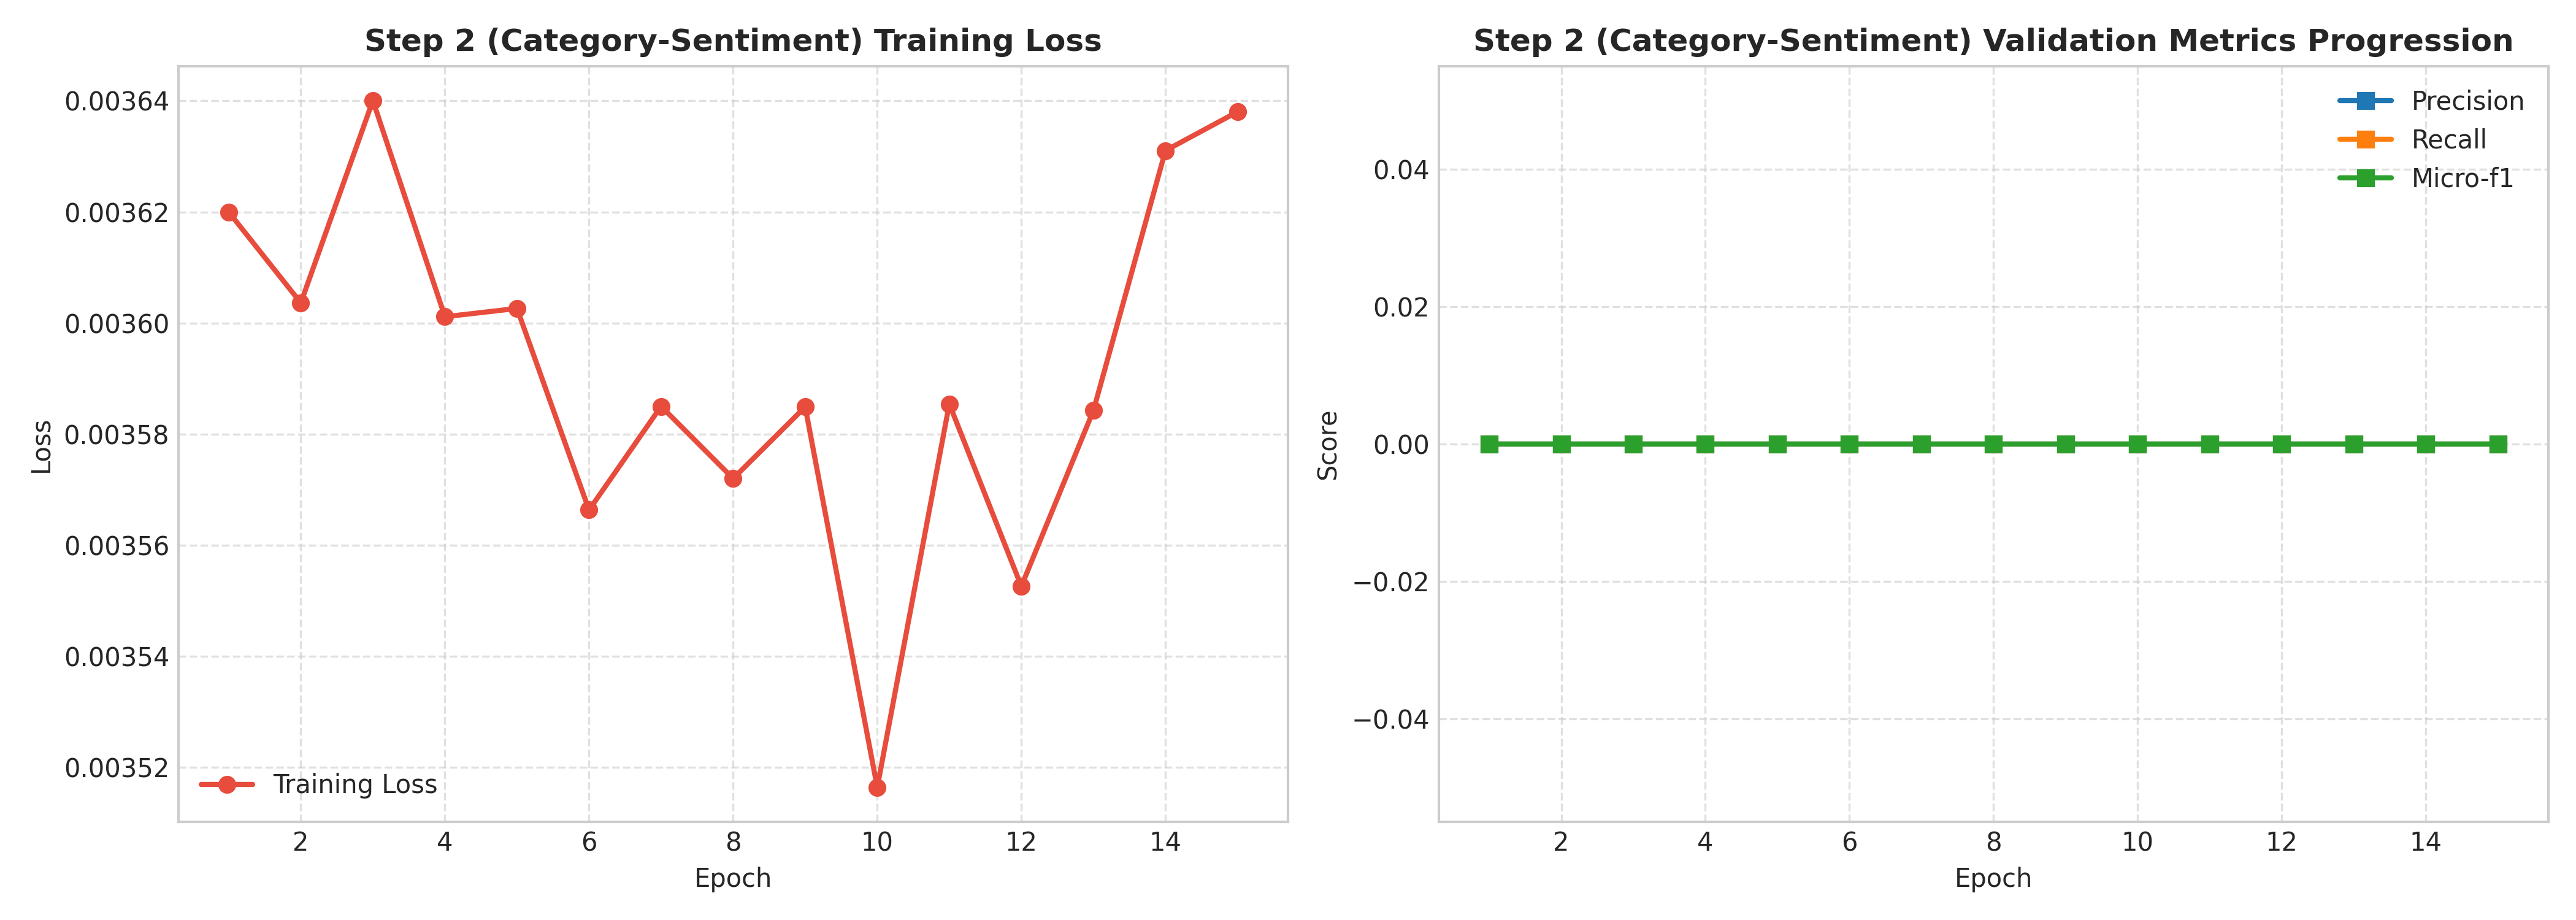

   [4/5]    0.8s  Manifest → STEP2_COMPLETED, pipeline_state.pkl diperbarui
✅ 8f. Plot, tabel laporan, manifest & state Step 2 — selesai dalam 0.8s



In [45]:
require_vars("step_stage", "step2_history", "best_step2_f1", "best2_epoch")

with step_stage("8f. Plot, tabel laporan, manifest & state Step 2", 5) as st:
    _p2 = os.path.join(plots_dir, "04_step2_training_loss_f1_curve.png")
    if step2_history:
        plot_training_history(
            step2_history, task_name="Step 2 (Category-Sentiment)",
            output_plot_path=_p2, output_csv_path=step2_csv
        )
        st.step(f"Plot & CSV riwayat ditulis ({len(step2_history)} epoch)")
    else:
        st.step("Riwayat kosong — plot dilewati")

    rep.section("5. Step 2: klasifikasi category & sentiment")
    df_s2 = pd.DataFrame(step2_history)
    if not df_s2.empty:
        df_s2_pct = df_s2.copy()
        for c in ["precision", "recall", "micro-F1"]:
            if c in df_s2_pct.columns and df_s2_pct[c].max() <= 1.0:
                df_s2_pct[c] = (df_s2_pct[c] * 100).round(2)
        _src_txt = 'prediksi step 1' if globals().get('pakai_1st', True) else 'gold pair'
        export_step_table(df_s2_pct, name="master_06_step2_riwayat", csv_dir=csv_dir,
                          md_dir=md_dir,
                          title=f"Riwayat Training Step 2 ({DOMAIN.upper()})",
                          notes=("Metrik pada level quadruple lengkap. Sumber kandidat: "
                                 f"{_src_txt}."),
                          max_rows_md=NUM_EPOCHS)
        rep.table(df_s2_pct, max_rows=NUM_EPOCHS, caption="Metrik step 2 per epoch")
        st.step(f"Tabel master_06_step2_riwayat diekspor (sumber kandidat: {_src_txt})")

        best2 = df_s2_pct.loc[df_s2_pct["micro-F1"].idxmax()]
        rep.kv({
            "epoch_terbaik": int(best2.get("epoch", best2_epoch)),
            "micro-F1_terbaik": f"{float(best2['micro-F1']):.2f}%",
            "checkpoint": step2_ckpt,
        })
        st.step(f"Micro-F1 terbaik {float(best2['micro-F1']):.2f}% "
                f"(epoch {int(best2.get('epoch', best2_epoch))})")
    else:
        st.step("Tabel riwayat dilewati (tidak ada metrik per epoch)")

    if os.path.exists(_p2):
        from IPython.display import Image, display
        display(Image(_p2))
        rep.image(_p2, "Kurva training step 2")

    update_mcp_manifest("STEP2_COMPLETED", 5, {
        "step2_best_micro_f1": float(best_step2_f1 * 100 if best_step2_f1 <= 1.0 else best_step2_f1),
        "step2_checkpoint": step2_ckpt
    })
    save_pipeline_state({"best_step2_f1": best_step2_f1, "best_step2_epoch": best2_epoch})
    st.step("Manifest → STEP2_COMPLETED, pipeline_state.pkl diperbarui")

## 9. Evaluasi Final & Benchmark Sub-Task

### 9a. Evaluasi Quadruple dengan Checkpoint Terbaik
Memuat checkpoint Step 2 terbaik lalu menjalankan `pair_eval` sekali sambil menangkap
metrik per sub-task. Hasilnya di-cache ke `logs/master_metrics.json`; set
`FORCE_REEVAL = True` untuk mengevaluasi ulang.

In [46]:
ensure_objects()
require_vars("step_stage", "session_dirs")

# Evaluasi Final Memakai Checkpoint Model Step 2 Terbaik
FORCE_REEVAL = False

import logging
from modeling import CategorySentiClassification
from eval_metrics import pair_eval
from colab_utils import SubtaskMetricCapture, plot_subtask_metrics

with step_stage("9a. Evaluasi final quadruple + metrik sub-task", 5) as st:
    metrics_json = os.path.join(session_dirs["logs"], "master_metrics.json")
    cached_metrics_available = os.path.exists(metrics_json)
    st.step(f"Cache metrik: {'ada' if cached_metrics_available else 'belum ada'} "
            f"({metrics_json}) | FORCE_REEVAL={FORCE_REEVAL}")

    if not FORCE_REEVAL and cached_metrics_available:
        with open(metrics_json, "r", encoding="utf-8") as jf:
            cached_all = json.load(jf)
        final_res = cached_all.get("overall", {})
        subtask_metrics = cached_all.get("subtasks", {})
        df_subtasks = pd.DataFrame([
            {"Subtask": k, "Precision": v.get("precision", 0.0),
             "Recall": v.get("recall", 0.0), "Micro_F1": v.get("micro-F1", 0.0),
             "N_Elements": len(k.split())}
            for k, v in subtask_metrics.items()
        ])
        st.step(f"[CACHE HIT] {len(final_res)} metrik keseluruhan, "
                f"{len(df_subtasks)} sub-task dimuat tanpa evaluasi ulang")
    else:
        if "eval_loader_2" not in globals() or "eval_gold_2" not in globals():
            raise RuntimeError(
                "Loader evaluasi Step 2 belum ada di memori dan master_metrics.json "
                "belum tersimpan. Jalankan sel 8c (dan 8a-8b) lebih dulu.")
        require_vars("args_h", "num_labels_step2", "label_list_step2")

        step2_ckpt_dir = session_dirs["step2_checkpoint"]
        os.makedirs(step2_ckpt_dir, exist_ok=True)
        step2_bin_path = os.path.join(step2_ckpt_dir, "pytorch_model.bin")

        # 1. Recovery langsung dari memori aktif (jika model_step2 baru saja dilatih di sel 8d/8e)
        if not os.path.exists(step2_bin_path) and "model_step2" in globals() and model_step2 is not None:
            torch.save(model_step2.state_dict(), step2_bin_path)
            if hasattr(model_step2, "config"):
                model_step2.config.to_json_file(os.path.join(step2_ckpt_dir, "config.json"))
            if "tokenizer" in globals() and tokenizer is not None:
                tokenizer.save_vocabulary(step2_ckpt_dir)
            st.note(f"💾 Checkpoint Step 2 berhasil disimpan dari model aktif di memori runtime → {step2_bin_path}")

        # 2. Fallback pencarian berkas lintas direktori sesi di Drive maupun lokal
        if not os.path.exists(step2_bin_path):
            _search_roots = [
                session_dirs.get("root", ""),
                results_base if 'results_base' in globals() else "",
                "/content/drive/MyDrive/ACOS/Output/results",
                "/content/drive/MyDrive/ACOS/results",
                "/content/drive/MyDrive/ACOS-ASLI/Output/results",
                "/content/drive/MyDrive/ACOS-ASLI/results",
                os.path.join(base_project_dir, "Output", "results") if 'base_project_dir' in globals() else "",
                os.path.join(base_project_dir, "results") if 'base_project_dir' in globals() else "",
            ]
            found_bin2 = auto_find_file("pytorch_model.bin", search_roots=_search_roots,
                                        must_contain="step2_best",
                                        domain=DOMAIN if 'DOMAIN' in globals() else None)
            if found_bin2 and os.path.exists(found_bin2):
                shutil.copy(found_bin2, step2_bin_path)
                src_dir2 = os.path.dirname(found_bin2)
                for fn in ["config.json", "vocab.txt"]:
                    fp = os.path.join(src_dir2, fn)
                    if os.path.exists(fp):
                        shutil.copy(fp, os.path.join(step2_ckpt_dir, fn))
                st.note(f"↪ Checkpoint Step 2 disalin dari {found_bin2}")

        # 3. Fallback darurat ke BERT pretrained cache jika checkpoint belum tersedia sama sekali
        if not os.path.exists(step2_bin_path):
            _bert_bin = os.path.join(bert_cache_dir, "pytorch_model.bin") if 'bert_cache_dir' in globals() else ""
            if _bert_bin and os.path.exists(_bert_bin):
                shutil.copy(_bert_bin, step2_bin_path)
                st.note(f"⚠️ Checkpoint Step 2 belum ada; menggunakan pretrained BERT cache sebagai fallback: {_bert_bin}")

        # 4. Pastikan file konfigurasi pendukung (config.json & vocab.txt) selalu ada
        for fn in ["config.json", "vocab.txt"]:
            dst_fp = os.path.join(step2_ckpt_dir, fn)
            if not os.path.exists(dst_fp) and 'bert_cache_dir' in globals():
                src_fp = os.path.join(bert_cache_dir, fn)
                if os.path.exists(src_fp):
                    shutil.copy(src_fp, dst_fp)

        if not os.path.exists(step2_bin_path):
            raise FileNotFoundError(
                f"Checkpoint Step 2 tidak ada di {step2_bin_path}. Jalankan sel 8e dulu.")
        st.step(f"Checkpoint dipakai: {step2_bin_path} "
                f"({os.path.getsize(step2_bin_path) / 1024 ** 2:.1f} MB)")

        model_step2_best = CategorySentiClassification.from_pretrained(
            session_dirs["step2_checkpoint"], num_labels=num_labels_step2).to(device)
        model_step2_best.eval()
        st.step(f"Model terbaik dimuat ke {device} dan diset ke mode eval")

        logger_final = logging.getLogger("Final_Eval")
        print(f"   Menjalankan pair_eval pada {len(eval_loader_2)} batch...", flush=True)
        with SubtaskMetricCapture(logger_final) as cap:
            final_res = pair_eval("final", args_h, logger_final, tokenizer, model_step2_best,
                                  eval_loader_2, eval_gold_2, label_list_step2, device,
                                  "categorysenti", eval_type="test")
        subtask_metrics = cap.to_dict()
        df_subtasks = cap.to_frame()
        st.step(f"pair_eval selesai: micro-F1 {final_res.get('micro-F1', 0.0) * 100:.2f}%, "
                f"{len(df_subtasks)} sub-task tertangkap")

        with open(metrics_json, "w", encoding="utf-8") as jf:
            json.dump({"overall": final_res, "subtasks": subtask_metrics,
                       "step1_history": globals().get("step1_history", []),
                       "step2_history": globals().get("step2_history", []),
                       "sumber_kandidat": "step1" if globals().get("pakai_1st", True) else "gold"},
                      jf, indent=2)
        st.step(f"master_metrics.json tersimpan: {metrics_json}")

    print("\n🏆 Metrik Quadruple Akhir:")
    for k, v in final_res.items():
        print(f"   {k:15s}: {v * 100:.2f}%")

▶️  9a. Evaluasi final quadruple + metrik sub-task
   [1/5]    0.0s  Cache metrik: belum ada (/content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/logs/master_metrics.json) | FORCE_REEVAL=False
   [2/5]    0.0s  Checkpoint dipakai: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/checkpoints/step2_best/pytorch_model.bin (417.9 MB)
   [3/5]    2.5s  Model terbaik dimuat ke cuda dan diset ke mode eval
   Menjalankan pair_eval pada 91 batch...


INFO:Final_Eval:***** category results *****
INFO:Final_Eval:  micro-F1 = 0.00%
INFO:Final_Eval:  precision = 0.00%
INFO:Final_Eval:  recall = 0.00%
INFO:Final_Eval:-----------------------------------
INFO:Final_Eval:***** sentiment results *****
INFO:Final_Eval:  micro-F1 = 0.00%
INFO:Final_Eval:  precision = 0.00%
INFO:Final_Eval:  recall = 0.00%
INFO:Final_Eval:-----------------------------------
INFO:Final_Eval:***** category sentiment results *****
INFO:Final_Eval:  micro-F1 = 0.00%
INFO:Final_Eval:  precision = 0.00%
INFO:Final_Eval:  recall = 0.00%
INFO:Final_Eval:-----------------------------------
INFO:Final_Eval:***** aspect results *****
INFO:Final_Eval:  micro-F1 = 0.00%
INFO:Final_Eval:  precision = 0.00%
INFO:Final_Eval:  recall = 0.00%
INFO:Final_Eval:-----------------------------------
INFO:Final_Eval:***** category aspect results *****
INFO:Final_Eval:  micro-F1 = 0.00%
INFO:Final_Eval:  precision = 0.00%
INFO:Final_Eval:  recall = 0.00%
INFO:Final_Eval:---------------

Quad num: 1106
tp: 0.0. fp: 1103.0. fn: 895.0.
tp: 0.0. fp: 0.0. fn: 490.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 142.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 98.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 102.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 565.0. fn: 715.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 399.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 123.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 85.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 95.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 520.0. fn: 623.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 497.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 144.0.
1 :  {'precision': 0, 'recal

### 9b. Tabel & Plot Benchmark
Sel pelaporan murni: aman diulang tanpa menyentuh GPU.

▶️  9b. Tabel & plot benchmark sub-task
=== Metrik Akhir Ekstraksi Quadruple (REST16) (6 baris) ===


,Metrik,Nilai,Persen
0,precision,0.0,0.0
1,recall,0.0,0.0
2,micro-F1,0.0,0.0
3,tp,0.0,0.0
4,fp,1103.0,110300.0
5,fn,895.0,89500.0


[tabel] CSV: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/csv/master_07_metrik_quadruple_final.csv | MD: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/md/master_07_metrik_quadruple_final.md
   [1/5]    0.0s  Tabel master_07 diekspor | sumber kandidat: prediksi step 1 (skor pipeline penuh)
=== Metrik per Sub-Task (REST16) - 15 kombinasi (15 baris) ===


,Subtask,N_Elements,Precision,Recall,Micro_F1
0,category,1,0.0,0.0,0.0
1,sentiment,1,0.0,0.0,0.0
2,aspect,1,0.0,0.0,0.0
3,opinion,1,0.0,0.0,0.0
4,category sentiment,2,0.0,0.0,0.0
5,category aspect,2,0.0,0.0,0.0
6,sentiment aspect,2,0.0,0.0,0.0
7,category opinion,2,0.0,0.0,0.0
8,sentiment opinion,2,0.0,0.0,0.0
9,aspect opinion,2,0.0,0.0,0.0


[tabel] CSV: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/csv/master_08_metrik_subtask.csv | MD: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/md/master_08_metrik_subtask.md
   [2/5]    0.1s  Tabel master_08 diekspor (15 sub-task)


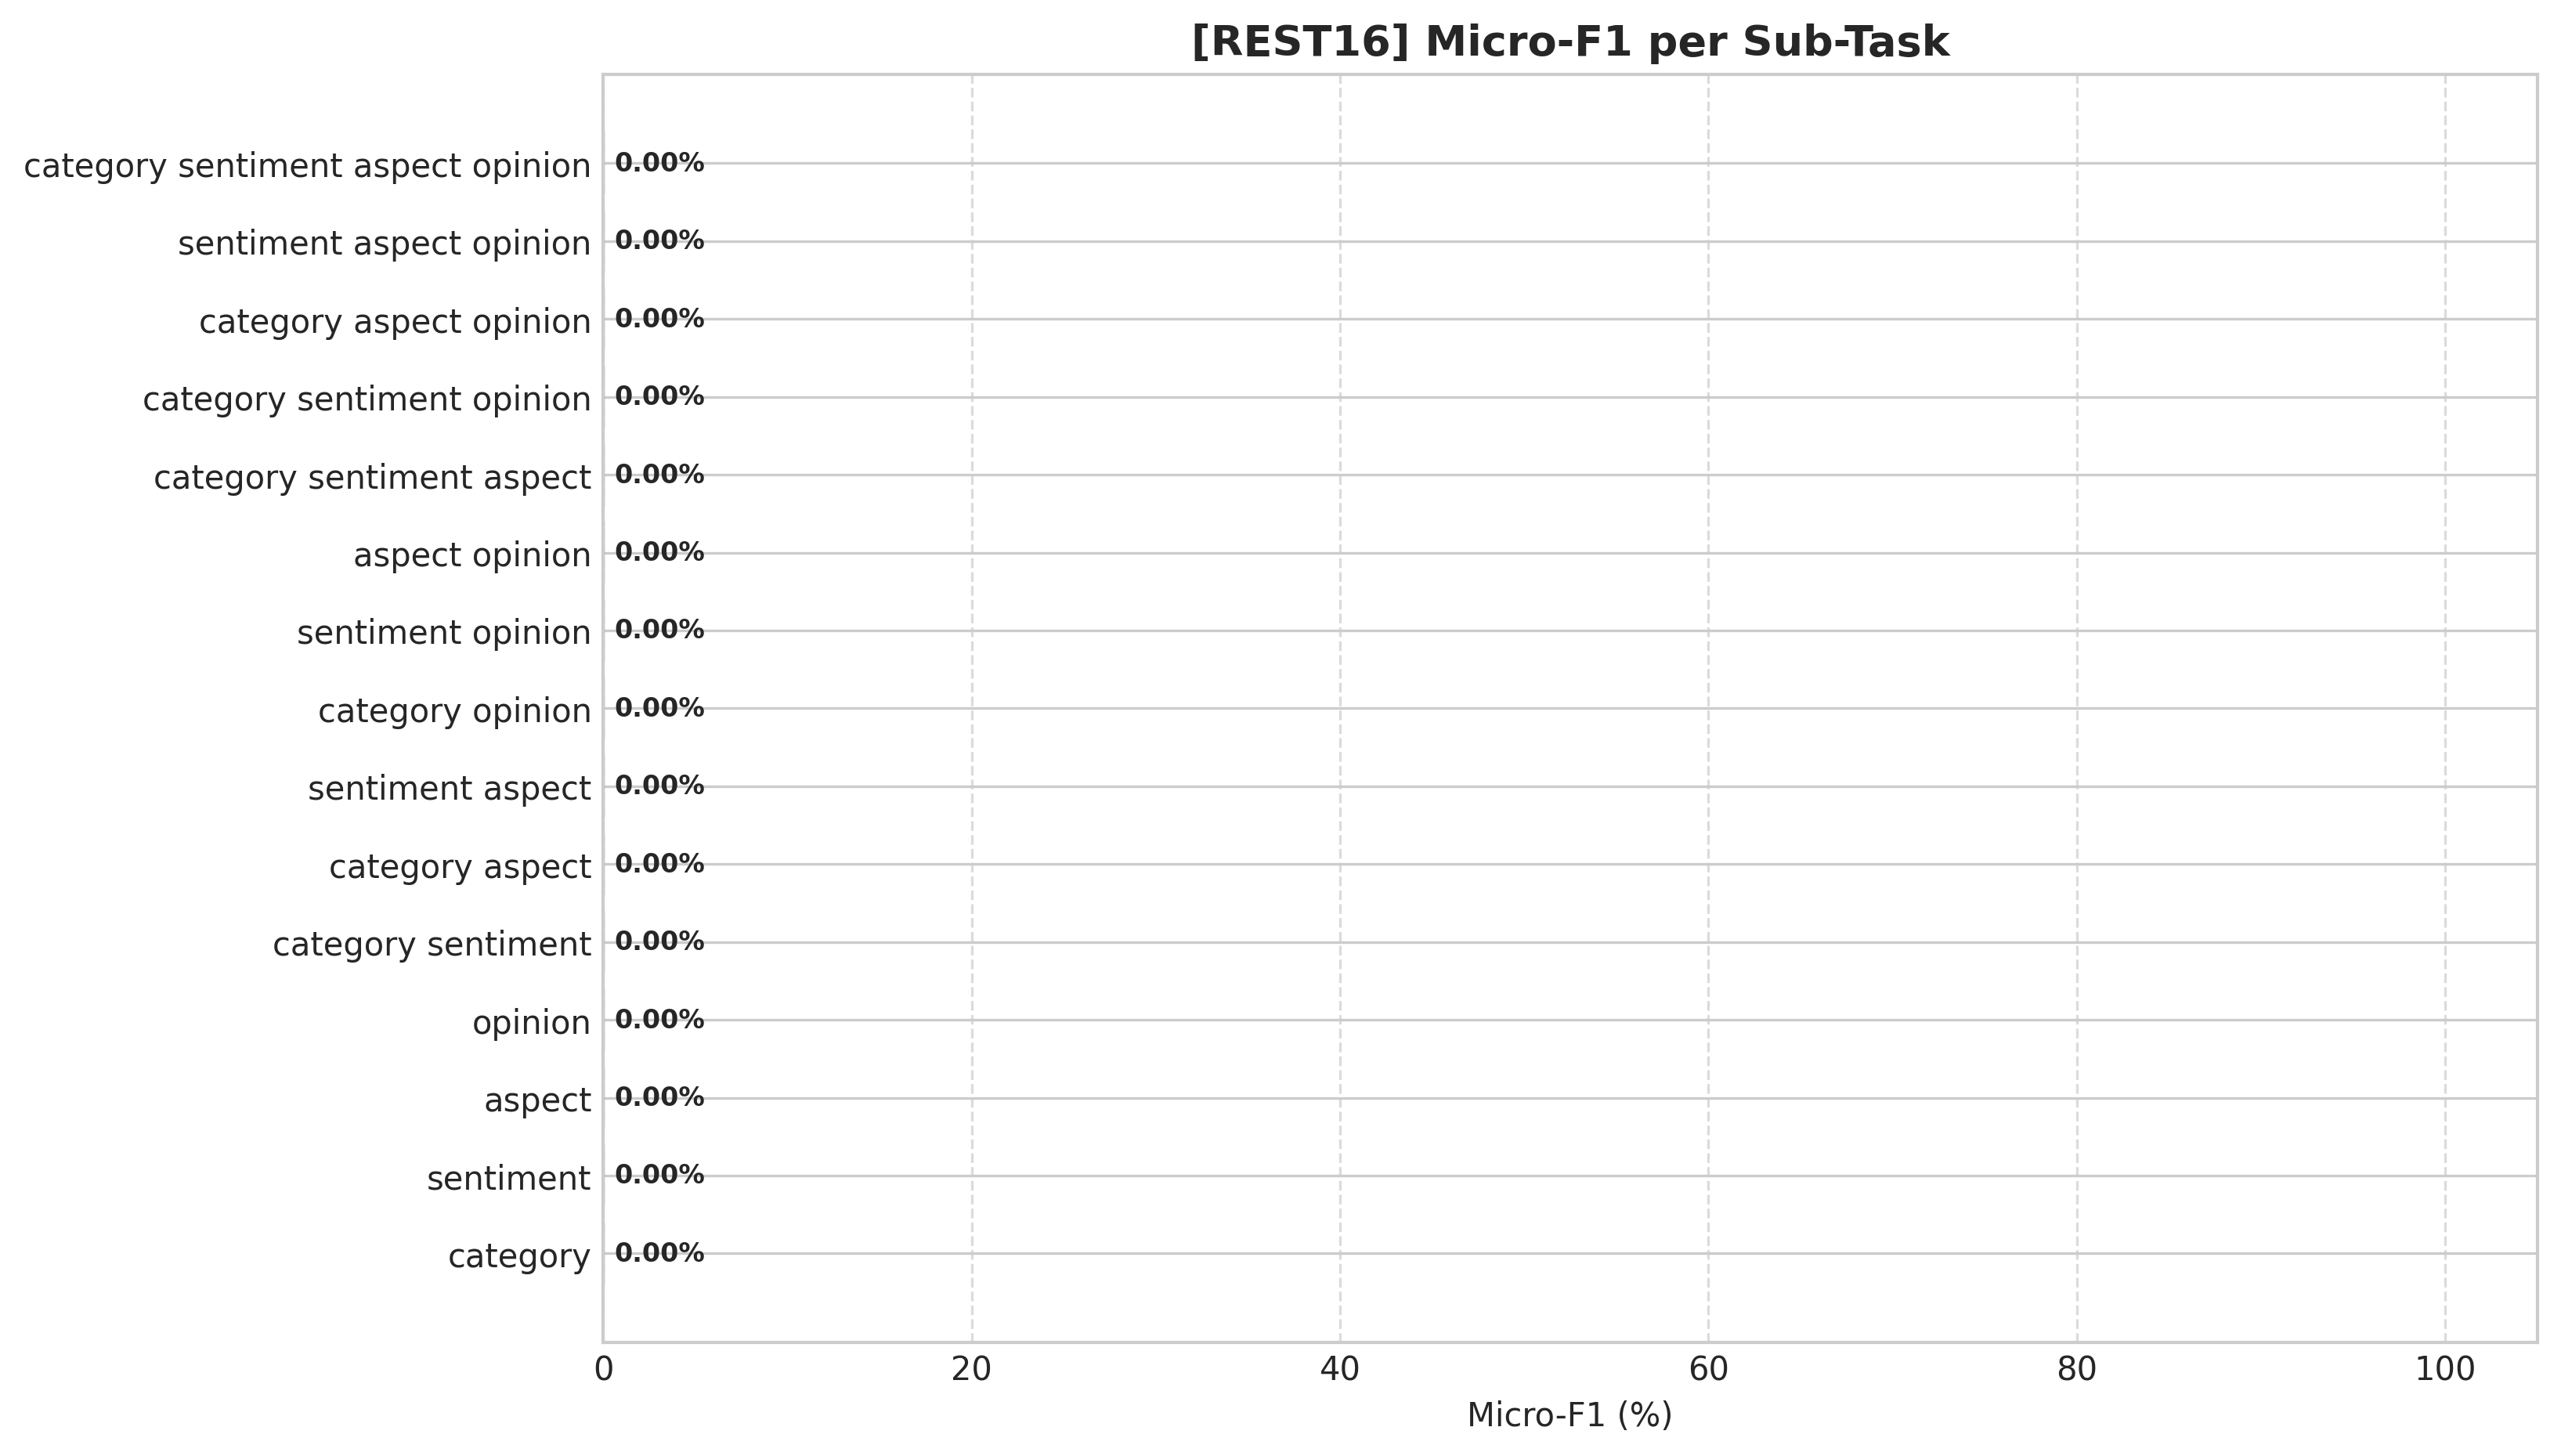

[plot] Disimpan: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/plots/05_benchmark_subtasks_f1.png
   [3/5]    1.0s  Plot benchmark disimpan: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/plots/05_benchmark_subtasks_f1.png
=== Micro-F1 Menurut Jumlah Elemen (REST16) (4 baris) ===


,N_Elements,Jumlah_Subtask,Micro_F1_Rata2,Micro_F1_Min,Micro_F1_Maks
0,1,4,0.0,0.0,0.0
1,2,6,0.0,0.0,0.0
2,3,4,0.0,0.0,0.0
3,4,1,0.0,0.0,0.0


[tabel] CSV: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/csv/master_09_agregasi_elemen.csv | MD: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/md/master_09_agregasi_elemen.md
   [4/5]    1.1s  Agregasi per jumlah elemen diekspor (4 baris)
   [5/5]    1.1s  Manifest → FINAL_EVAL_COMPLETED, pipeline_state.pkl diperbarui
✅ 9b. Tabel & plot benchmark sub-task — selesai dalam 1.1s



In [47]:
require_vars("step_stage", "final_res", "df_subtasks")

with step_stage("9b. Tabel & plot benchmark sub-task", 5) as st:
    rep.section("6. Hasil akhir pipeline")
    df_overall = pd.DataFrame([{
        "Metrik": k, "Nilai": v, "Persen": round(v * 100, 2),
    } for k, v in final_res.items()])
    _sumber = ('prediksi step 1 (skor pipeline penuh)' if globals().get('pakai_1st', True)
               else 'gold pair (step 2 terisolasi)')
    export_step_table(df_overall, name="master_07_metrik_quadruple_final",
                      csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Metrik Akhir Ekstraksi Quadruple ({DOMAIN.upper()})",
                      notes=f"Sumber kandidat: {_sumber}.")
    rep.table(df_overall, caption="Metrik quadruple akhir")
    st.step(f"Tabel master_07 diekspor | sumber kandidat: {_sumber}")

    if not df_subtasks.empty:
        df_sub_pct = df_subtasks.copy()
        for c in ["Precision", "Recall", "Micro_F1"]:
            if c in df_sub_pct.columns and df_sub_pct[c].max() <= 1.0:
                df_sub_pct[c] = (df_sub_pct[c] * 100).round(2)

        rep.section("7. Metrik per sub-task")
        export_step_table(df_sub_pct, name="master_08_metrik_subtask", csv_dir=csv_dir,
                          md_dir=md_dir,
                          title=f"Metrik per Sub-Task ({DOMAIN.upper()}) - {len(df_sub_pct)} kombinasi",
                          notes="Diambil dari keluaran pair_eval sesi ini, bukan angka manual.",
                          max_rows_md=20)
        rep.table(df_sub_pct, max_rows=20, caption="Metrik per sub-task")
        st.step(f"Tabel master_08 diekspor ({len(df_sub_pct)} sub-task)")

        _ps = os.path.join(plots_dir, "05_benchmark_subtasks_f1.png")
        plot_subtask_metrics(df_subtasks, _ps,
                             title=f"[{DOMAIN.upper()}] Micro-F1 per Sub-Task")
        rep.image(_ps, "Micro-F1 per sub-task")
        st.step(f"Plot benchmark disimpan: {_ps}")

        df_agg = (df_subtasks.groupby("N_Elements")
                  .agg(Jumlah_Subtask=("Subtask", "count"),
                       Micro_F1_Rata2=("Micro_F1", "mean"),
                       Micro_F1_Min=("Micro_F1", "min"),
                       Micro_F1_Maks=("Micro_F1", "max"))
                  .reset_index())
        for c in ["Micro_F1_Rata2", "Micro_F1_Min", "Micro_F1_Maks"]:
            if df_agg[c].max() <= 1.0:
                df_agg[c] = (df_agg[c] * 100).round(2)
        export_step_table(df_agg, name="master_09_agregasi_elemen", csv_dir=csv_dir,
                          md_dir=md_dir,
                          title=f"Micro-F1 Menurut Jumlah Elemen ({DOMAIN.upper()})")
        rep.table(df_agg, caption="Agregasi per jumlah elemen")
        st.step(f"Agregasi per jumlah elemen diekspor ({len(df_agg)} baris)")
    else:
        st.step("df_subtasks kosong — tabel dan plot sub-task dilewati")

    update_mcp_manifest("FINAL_EVAL_COMPLETED", 6, {
        "final_metrics": final_res, "metrics_json_path": metrics_json
    })
    save_pipeline_state({"final_res": final_res})
    st.step("Manifest → FINAL_EVAL_COMPLETED, pipeline_state.pkl diperbarui")

## 10. Live Interactive Inference Demo pada Teks Ulasan Bebas

In [48]:
ensure_objects()
import re as _re

# Kelas model diimpor di sel 12 & 22; ambil ulang bila sel ini dijalankan
# sendiri sesudah pemulihan state.
from modeling import BertForQuadABSA, CategorySentiClassification


In [49]:

# Muat model Step 1 & Step 2 terbaik untuk inferensi live (dengan fallback auto-load)
step1_best_path = session_dirs["step1_checkpoint"]
if not os.path.exists(os.path.join(step1_best_path, "pytorch_model.bin")):
    found_b1 = auto_find_file("pytorch_model.bin", must_contain="step1_best")
    if found_b1 and "step1_best" in found_b1:
        step1_best_path = os.path.dirname(found_b1)

step2_best_path = session_dirs["step2_checkpoint"]
if not os.path.exists(os.path.join(step2_best_path, "pytorch_model.bin")):
    found_b2 = auto_find_file("pytorch_model.bin", must_contain="step2_best")
    if found_b2 and "step2_best" in found_b2:
        step2_best_path = os.path.dirname(found_b2)

model_step1_best = BertForQuadABSA.from_pretrained(
    step1_best_path, num_labels=num_labels_step1).to(device)
model_step1_best.eval()

model_step2_best = CategorySentiClassification.from_pretrained(
    step2_best_path, num_labels=num_labels_step2).to(device)
model_step2_best.eval()

_catsenti_labels = label_list_step2[0]

def _spans_dari_tag(tag_ids):
    s = "".join(str(t) for t in tag_ids)
    aspects = [(m.start() - 1, m.end() - 1) for m in _re.finditer(r"32*", s)]
    opinions = [(m.start() - 1, m.end() - 1) for m in _re.finditer(r"54*", s)]
    return aspects, opinions


In [50]:

def analyze_review_quadruples(review_text, domain=None, ambang=0.0, tampilkan_proses=True):
    """Ekstraksi quadruple dua tahap untuk satu teks ulasan bebas."""
    domain = domain or DOMAIN
    max_len = MAX_SEQ_LENGTH

    tokens = tokenizer.tokenize(review_text.lower())[: max_len - 2]
    input_tokens = ["[CLS]"] + tokens + ["[SEP]"]
    input_ids = tokenizer.convert_tokens_to_ids(input_tokens)
    attn = [1] * len(input_ids)
    seg = [0] * len(input_ids)
    while len(input_ids) < max_len:
        input_ids.append(0)
        attn.append(0)
        seg.append(0)

    t_ids = torch.tensor([input_ids], dtype=torch.long).to(device)
    t_attn = torch.tensor([attn], dtype=torch.long).to(device)
    t_seg = torch.tensor([seg], dtype=torch.long).to(device)
    t_dummy = torch.zeros((1, max_len), dtype=torch.long).to(device)
    t_zero = torch.zeros(1, dtype=torch.long).to(device)

    with torch.no_grad():
        out1 = model_step1_best(
            aspect_input_ids=t_ids, aspect_labels=t_dummy,
            aspect_token_type_ids=t_seg, aspect_attention_mask=t_attn,
            exist_imp_aspect=t_zero, exist_imp_opinion=t_zero,
        )
    _, logits1 = unpack_model_output(out1)
    pred_tags, imp_a_logit, imp_o_logit = logits1
    imp_aspect = int(imp_a_logit.argmax(-1).item()) == 1
    imp_opinion = int(imp_o_logit.argmax(-1).item()) == 1

    aspects, opinions = _spans_dari_tag(pred_tags[0])
    if imp_aspect or not aspects:
        aspects = aspects + [(-1, -1)]
    if imp_opinion or not opinions:
        opinions = opinions + [(-1, -1)]

    if tampilkan_proses:
        print(f"\nTeks Review : {review_text}")
        print(f"Tokens      : {tokens}")
        print(f"Aspect Spans: {aspects} (implicit={imp_aspect})")
        print(f"Opinion Span: {opinions} (implicit={imp_opinion})")

    hasil = []
    for (a_st, a_ed) in aspects:
        for (o_st, o_ed) in opinions:
            cand_a = [0] * max_len
            cand_o = [0] * max_len
            if a_st == -1:
                cand_a[0] = 1
            else:
                for i in range(a_st + 1, a_ed + 1):
                    if i < max_len: cand_a[i] = 1
            if o_st == -1:
                cand_o[len(tokens) + 1] = 1
            else:
                for i in range(o_st + 1, o_ed + 1):
                    if i < max_len: cand_o[i] = 1

            with torch.no_grad():
                out2 = model_step2_best(
                    tokenizer, 0,
                    aspect_input_ids=t_ids,
                    aspect_token_type_ids=t_seg,
                    aspect_attention_mask=t_attn,
                    candidate_aspect=torch.tensor([cand_a], dtype=torch.long).to(device),
                    candidate_opinion=torch.tensor([cand_o], dtype=torch.long).to(device),
                    label_id=torch.zeros((1, num_labels_step2), dtype=torch.float).to(device),
                )
            _, logits2 = unpack_model_output(out2)
            skor = logits2[0][0].detach().cpu().numpy()

            aktif = [i for i, v in enumerate(skor) if v > ambang] or [int(skor.argmax())]
            asp_txt = "[IMPLICIT]" if a_st == -1 else " ".join(tokens[a_st:a_ed])
            opi_txt = "[IMPLICIT]" if o_st == -1 else " ".join(tokens[o_st:o_ed])

            for idx in aktif:
                kategori, sentimen = _catsenti_labels[idx].rsplit("#", 1)
                hasil.append({
                    "Aspect": asp_txt,
                    "Aspect_Span": f"{a_st},{a_ed}",
                    "Category": kategori,
                    "Opinion": opi_txt,
                    "Opinion_Span": f"{o_st},{o_ed}",
                    "Sentiment": {"0": "negative", "1": "neutral", "2": "positive"}.get(sentimen, sentimen),
                    "Skor_Logit": round(float(skor[idx]), 4),
                    "Is_Implicit_Aspect": a_st == -1,
                    "Is_Implicit_Opinion": o_st == -1,
                })

    df = pd.DataFrame(hasil)
    if not df.empty:
        df = df.sort_values("Skor_Logit", ascending=False).reset_index(drop=True)
    return df

# Contoh Pengujian Live Review
sample_review = "The sushi was fresh and delicious, but the service was slow."
df_infer = analyze_review_quadruples(sample_review, domain=DOMAIN)

rep.section("8. Contoh inferensi")
rep.text(f"Teks: `{sample_review}`")
if not df_infer.empty:
    export_step_table(df_infer, name="master_10_contoh_inferensi", csv_dir=csv_dir, md_dir=md_dir,
                      title="Quadruple Hasil Inferensi Contoh",
                      notes="Skor_Logit adalah keluaran mentah sebelum sigmoid; ambang default 0.0.",
                      max_rows_md=20)
    rep.table(df_infer, max_rows=20, caption="Quadruple hasil inferensi")
    from IPython.display import display
    display(df_infer)

save_pipeline_state({"df_infer": df_infer})

/usr/local/lib/python3.13/dist-packages/torchcrf/__init__.py:249: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at /pytorch/aten/src/ATen/native/TensorCompare.cpp:614.)
  score = torch.where(mask[i].unsqueeze(1), next_score, score)



Teks Review : The sushi was fresh and delicious, but the service was slow.
Tokens      : ['the', 'su', '##shi', 'was', 'fresh', 'and', 'delicious', ',', 'but', 'the', 'service', 'was', 'slow', '.']
Aspect Spans: [(1, 3), (10, 11), (-1, -1)] (implicit=True)
Opinion Span: [(4, 5), (6, 7), (12, 13)] (implicit=False)
=== Quadruple Hasil Inferensi Contoh (9 baris) ===


,Aspect,Aspect_Span,Category,Opinion,Opinion_Span,Sentiment,Skor_Logit,Is_Implicit_Aspect,Is_Implicit_Opinion
0,su ##shi,"1,3",FOOD#QUALITY,fresh,"4,5",positive,5.5050,False,False
1,su ##shi,"1,3",FOOD#QUALITY,delicious,"6,7",positive,5.4679,False,False
2,service,"10,11",SERVICE#GENERAL,slow,"12,13",negative,3.5715,False,False
3,[IMPLICIT],"-1,-1",SERVICE#GENERAL,slow,"12,13",negative,2.7649,True,False
4,su ##shi,"1,3",FOOD#QUALITY,slow,"12,13",positive,-0.3545,False,False
5,[IMPLICIT],"-1,-1",FOOD#QUALITY,fresh,"4,5",positive,-0.4403,True,False
6,[IMPLICIT],"-1,-1",FOOD#QUALITY,delicious,"6,7",positive,-0.4774,True,False
7,service,"10,11",FOOD#QUALITY,fresh,"4,5",positive,-0.7782,False,False
8,service,"10,11",FOOD#QUALITY,delicious,"6,7",positive,-0.8153,False,False


[tabel] CSV: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/csv/master_10_contoh_inferensi.csv | MD: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/md/master_10_contoh_inferensi.md


,Aspect,Aspect_Span,Category,Opinion,Opinion_Span,Sentiment,Skor_Logit,Is_Implicit_Aspect,Is_Implicit_Opinion
0,su ##shi,"1,3",FOOD#QUALITY,fresh,"4,5",positive,5.5050,False,False
1,su ##shi,"1,3",FOOD#QUALITY,delicious,"6,7",positive,5.4679,False,False
2,service,"10,11",SERVICE#GENERAL,slow,"12,13",negative,3.5715,False,False
3,[IMPLICIT],"-1,-1",SERVICE#GENERAL,slow,"12,13",negative,2.7649,True,False
4,su ##shi,"1,3",FOOD#QUALITY,slow,"12,13",positive,-0.3545,False,False
5,[IMPLICIT],"-1,-1",FOOD#QUALITY,fresh,"4,5",positive,-0.4403,True,False
6,[IMPLICIT],"-1,-1",FOOD#QUALITY,delicious,"6,7",positive,-0.4774,True,False
7,service,"10,11",FOOD#QUALITY,fresh,"4,5",positive,-0.7782,False,False
8,service,"10,11",FOOD#QUALITY,delicious,"6,7",positive,-0.8153,False,False


'/content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/pipeline_state.pkl'

## 11. Ringkasan Seluruh Artefak & Finalisasi Sesi

In [51]:
# Audit akhir seluruh artefak tersimpan di Google Drive / lokal
print("=" * 78)
print(f"🏁 AUDIT ARTEFAK SESI AKTIF [{DOMAIN.upper()}]")
print("=" * 78)
print(f"📁 Lokasi Penyimpanan: {session_dirs.get('root')}")
is_drive_saved = "/content/drive/MyDrive" in session_dirs.get("root", "")
print(f"🛡️  Persistensi Google Drive: {'✅ TERSIMPAN DI DRIVE' if is_drive_saved else '⚠️ LOKAL / EPHEMERAL'}\n")

all_saved_files = []
for sub_name, sub_path in session_dirs.items():
    if sub_name == "root" or not os.path.isdir(sub_path):
        continue
    for root, dirs, files in os.walk(sub_path):
        for f in sorted(files):
            fp = os.path.join(root, f)
            sz = os.path.getsize(fp)
            all_saved_files.append({
                "Subfolder": sub_name,
                "File": f,
                "Size": f"{sz / 1024:.1f} KB" if sz < 1024*1024 else f"{sz / (1024**2):.2f} MB",
                "Path": fp
            })

df_audit = pd.DataFrame(all_saved_files)
if not df_audit.empty:
    print(f"📦 Total {len(df_audit)} file berhasil diamankan di sesi ini:")
    for sf, grp in df_audit.groupby("Subfolder"):
        print(f"\n📂 [{sf.upper()}] ({len(grp)} file):")
        for r in grp.itertuples():
            print(f"   - {r.File:<42} ({r.Size})")
else:
    print("⚠️ Belum ada file tersimpan di subfolder sesi.")
print("=" * 78)


🏁 AUDIT ARTEFAK SESI AKTIF [REST16]
📁 Lokasi Penyimpanan: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817
🛡️  Persistensi Google Drive: ✅ TERSIMPAN DI DRIVE

📦 Total 54 file berhasil diamankan di sesi ini:

📂 [CHECKPOINTS] (6 file):
   - config.json                                (0.6 KB)
   - pytorch_model.bin                          (420.01 MB)
   - vocab.txt                                  (226.1 KB)
   - config.json                                (0.6 KB)
   - pytorch_model.bin                          (417.95 MB)
   - vocab.txt                                  (226.1 KB)

📂 [CSV] (18 file):
   - candidate_pairs_summary.csv                (167.2 KB)
   - eda_all_samples_annotated.csv              (510.0 KB)
   - eda_dataset_statistics.csv                 (0.3 KB)
   - labels_step1.json                          (0.1 KB)
   - labels_step2.json                          (1.0 KB)
   - master_00_konfigurasi.csv                  (0.2 KB)
   - master_01_statistik_datase